// alvi vai 

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# EXTENDED IMPORTS for Research Paper Figures
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestClassifier, VotingClassifier, StackingClassifier,
    GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier,
    ExtraTreesClassifier
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support, roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, log_loss
)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from itertools import cycle

# Research-paper quality settings
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
})

print("All imports loaded successfully.")

All imports loaded successfully.


In [2]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset (1).csv")


In [3]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [4]:
if "Person ID" in df.columns:
    df.drop(columns=["Person ID"], inplace=True)

df["BMI Category"] = df["BMI Category"].replace({"Normal Weight": "Normal"})

if "Blood Pressure" in df.columns:
    df[["Systolic_BP", "Diastolic_BP"]] = (
        df["Blood Pressure"].astype(str).str.split("/", expand=True).astype(int)
    )
    df.drop(columns=["Blood Pressure"], inplace=True)

X = df.drop(columns=["Sleep Disorder"])
y = df["Sleep Disorder"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['Insomnia' 'None' 'Sleep Apnea']


In [5]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [7]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    eval_metric="mlogloss",
    random_state=42
)


In [8]:
voting_clf = VotingClassifier(
    estimators=[("rf", rf), ("xgb", xgb)],
    voting="soft",
    n_jobs=None
)

In [9]:
voting_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", voting_clf)
])

In [10]:
voting_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Sleep Duration',
                                                   'Quality of Sleep',
                                                   'Physical Activity Level',
                                                   'Stress Level', 'Heart Rate',
                                                   'Daily Steps', 'Systolic_BP',
                                                   'Diastolic_BP']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Occupation',
                                                   'BMI Category'])])),
                ('classifier',
                 VotingClassifier(estimator...
                                                             grow_policy=None,
                                                             importance_type=None,
                                                             interaction_constraints=None,
                                                             learning_rate=0.05,
                                                             max_bin=None,
                                                             max_cat_threshold=None,
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=5,
                                                             max_leaves=None,
                                                             min_child_weight=None,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=200,
                                                             n_jobs=None,
                                                             num_parallel_tree=None,
                                                             random_state=42, ...))],
                                  voting='soft'))])

In [11]:
# ============================================================
# Evaluate the Voting Classifier
# ============================================================
y_pred = voting_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"VOTING ACCURACY: {acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

VOTING ACCURACY: 93.33%

Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.78      0.93      0.85        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.93      0.81      0.87        16

    accuracy                           0.93        75
   macro avg       0.90      0.91      0.90        75
weighted avg       0.94      0.93      0.93        75


Confusion Matrix:
 [[14  0  1]
 [ 1 43  0]
 [ 3  0 13]]


---
## 📊 Research Paper Figures & Comprehensive Analysis

The following cells generate publication-quality figures including:
1. Confusion Matrix Heatmap (Voting Classifier)
2. Multi-Model Comparison (Accuracy, F1, Precision, Recall, Kappa, MCC)
3. ROC Curves (per-class, multi-model)
4. Precision–Recall Curves
5. Learning Curves
6. Cross-Validation Box Plots
7. Ground-Truth vs. Model Output Prediction Curves (first 24 test steps)
8. Sensitivity to Histogram Bin Number
9. Effect of Histogram Bin Number on Forecasting Performance
10. Feature Correlation Heatmap
11. Class Distribution Analysis
12. Per-Class Metric Radar Chart
13. Training Time Comparison

### Figure 1: Confusion Matrix Heatmap — Voting Classifier

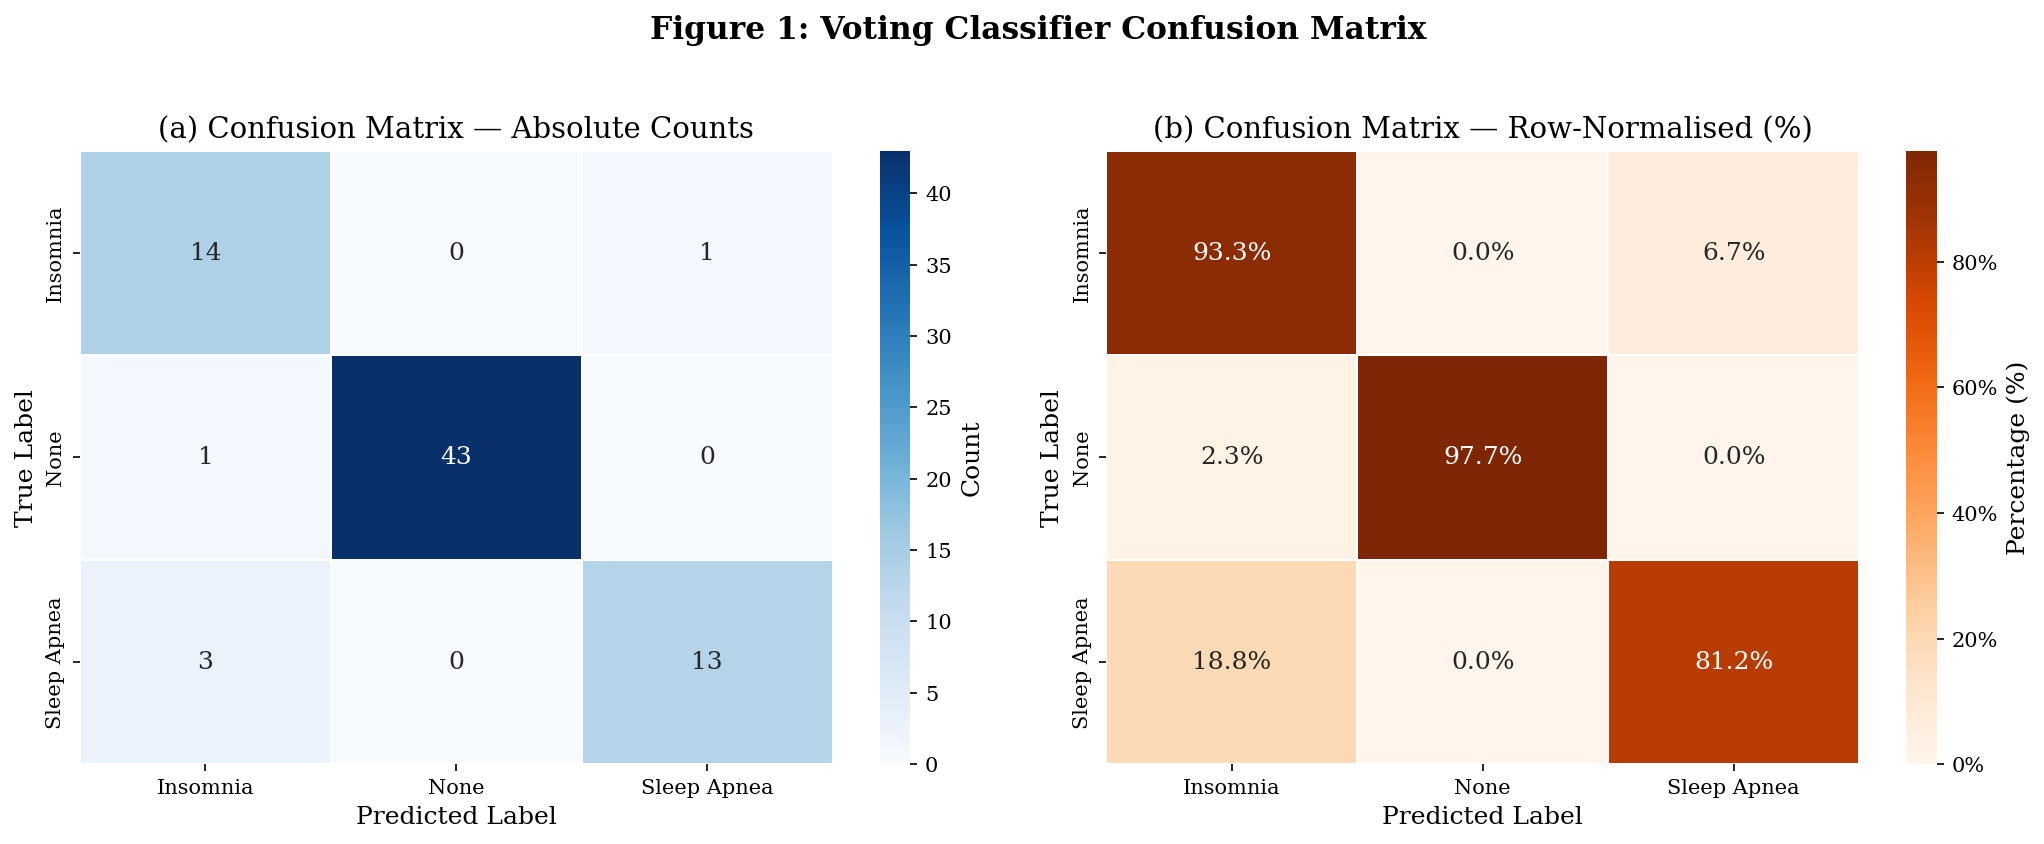

In [12]:
# ============================================================
# Figure 1: Publication-Quality Confusion Matrix Heatmap
# ============================================================
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) Absolute counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_,
            yticklabels=le.classes_, ax=axes[0], linewidths=0.8, linecolor='white',
            cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title('(a) Confusion Matrix \u2014 Absolute Counts')

# (b) Percentage
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges', xticklabels=le.classes_,
            yticklabels=le.classes_, ax=axes[1], linewidths=0.8, linecolor='white',
            cbar_kws={'label': 'Percentage (%)', 'format': '%.0f%%'})
for t in axes[1].texts:
    t.set_text(t.get_text() + '%')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_title('(b) Confusion Matrix \u2014 Row-Normalised (%)')

plt.suptitle('Figure 1: Voting Classifier Confusion Matrix', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Figure 2: Multi-Model Comparison — Train All Baseline & Ensemble Models

In [13]:
# ============================================================
# Train ALL models for comprehensive comparison
# ============================================================
import time

models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=4000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]),
    'K-Nearest Neighbors': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=5))
    ]),
    'SVM (RBF)': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC(kernel='rbf', probability=True, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(n_estimators=200, learning_rate=0.05,
                                     max_depth=5, eval_metric='mlogloss',
                                     random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(n_estimators=200,
                                                  learning_rate=0.05,
                                                  max_depth=5, random_state=42))
    ]),
    'AdaBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', AdaBoostClassifier(n_estimators=200, random_state=42))
    ]),
    'Extra Trees': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', ExtraTreesClassifier(n_estimators=200, random_state=42))
    ]),
    'Proposed Model (Voting)': voting_model,
}

results = {}
train_times = {}

for name, model in models.items():
    start = time.time()
    if name == 'Proposed Model (Voting)':
        # Already fitted
        pass
    else:
        model.fit(X_train, y_train)
    elapsed = time.time() - start
    train_times[name] = elapsed

    preds = model.predict(X_test)
    proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='weighted')
    acc = accuracy_score(y_test, preds)
    kappa = cohen_kappa_score(y_test, preds)
    mcc = matthews_corrcoef(y_test, preds)
    ll = log_loss(y_test, proba) if proba is not None else np.nan

    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1-Score': f1, 'Kappa': kappa, 'MCC': mcc,
        'Log Loss': ll, 'Predictions': preds, 'Probabilities': proba
    }
    print(f"{name:25s} | Acc={acc:.4f} | F1={f1:.4f} | Kappa={kappa:.4f} | MCC={mcc:.4f} | Time={elapsed:.3f}s")

results_df = pd.DataFrame({k: {m: v for m, v in vals.items() if m not in ('Predictions', 'Probabilities')}
                           for k, vals in results.items()}).T
results_df = results_df.sort_values('Accuracy', ascending=False)
print('\n')
results_df.style.format('{:.4f}').background_gradient(cmap='YlGn', axis=0)

Logistic Regression       | Acc=0.9467 | F1=0.9464 | Kappa=0.9072 | MCC=0.9092 | Time=0.213s
Decision Tree             | Acc=0.9467 | F1=0.9476 | Kappa=0.9081 | MCC=0.9091 | Time=0.007s
K-Nearest Neighbors       | Acc=0.9467 | F1=0.9467 | Kappa=0.9065 | MCC=0.9068 | Time=0.006s
SVM (RBF)                 | Acc=0.9733 | F1=0.9732 | Kappa=0.9532 | MCC=0.9544 | Time=0.051s
Random Forest             | Acc=0.9467 | F1=0.9472 | Kappa=0.9073 | MCC=0.9076 | Time=0.264s
XGBoost                   | Acc=0.9467 | F1=0.9466 | Kappa=0.9065 | MCC=0.9077 | Time=0.176s
Gradient Boosting         | Acc=0.9467 | F1=0.9472 | Kappa=0.9073 | MCC=0.9076 | Time=1.185s
AdaBoost                  | Acc=0.8267 | F1=0.8321 | Kappa=0.6990 | MCC=0.7005 | Time=0.289s
Extra Trees               | Acc=0.9333 | F1=0.9345 | Kappa=0.8842 | MCC=0.8862 | Time=0.195s
Proposed Model (Voting)   | Acc=0.9333 | F1=0.9345 | Kappa=0.8842 | MCC=0.8862 | Time=0.000s




,Accuracy,Precision,Recall,F1-Score,Kappa,MCC,Log Loss
SVM (RBF),0.9733,0.9763,0.9733,0.9732,0.9532,0.9544,0.1989
Logistic Regression,0.9467,0.9509,0.9467,0.9464,0.9072,0.9092,0.2009
Decision Tree,0.9467,0.9499,0.9467,0.9476,0.9081,0.9091,1.9991
K-Nearest Neighbors,0.9467,0.9474,0.9467,0.9467,0.9065,0.9068,0.1919
Random Forest,0.9467,0.9482,0.9467,0.9472,0.9073,0.9076,0.1900
XGBoost,0.9467,0.9495,0.9467,0.9466,0.9065,0.9077,0.1907
Gradient Boosting,0.9467,0.9482,0.9467,0.9472,0.9073,0.9076,0.3674
Extra Trees,0.9333,0.9403,0.9333,0.9345,0.8842,0.8862,1.5798
Proposed Model (Voting),0.9333,0.9403,0.9333,0.9345,0.8842,0.8862,0.1865
AdaBoost,0.8267,0.8413,0.8267,0.8321,0.6990,0.7005,1.0218


### Figure 2 (continued): Grouped Bar Chart — Model Performance Comparison

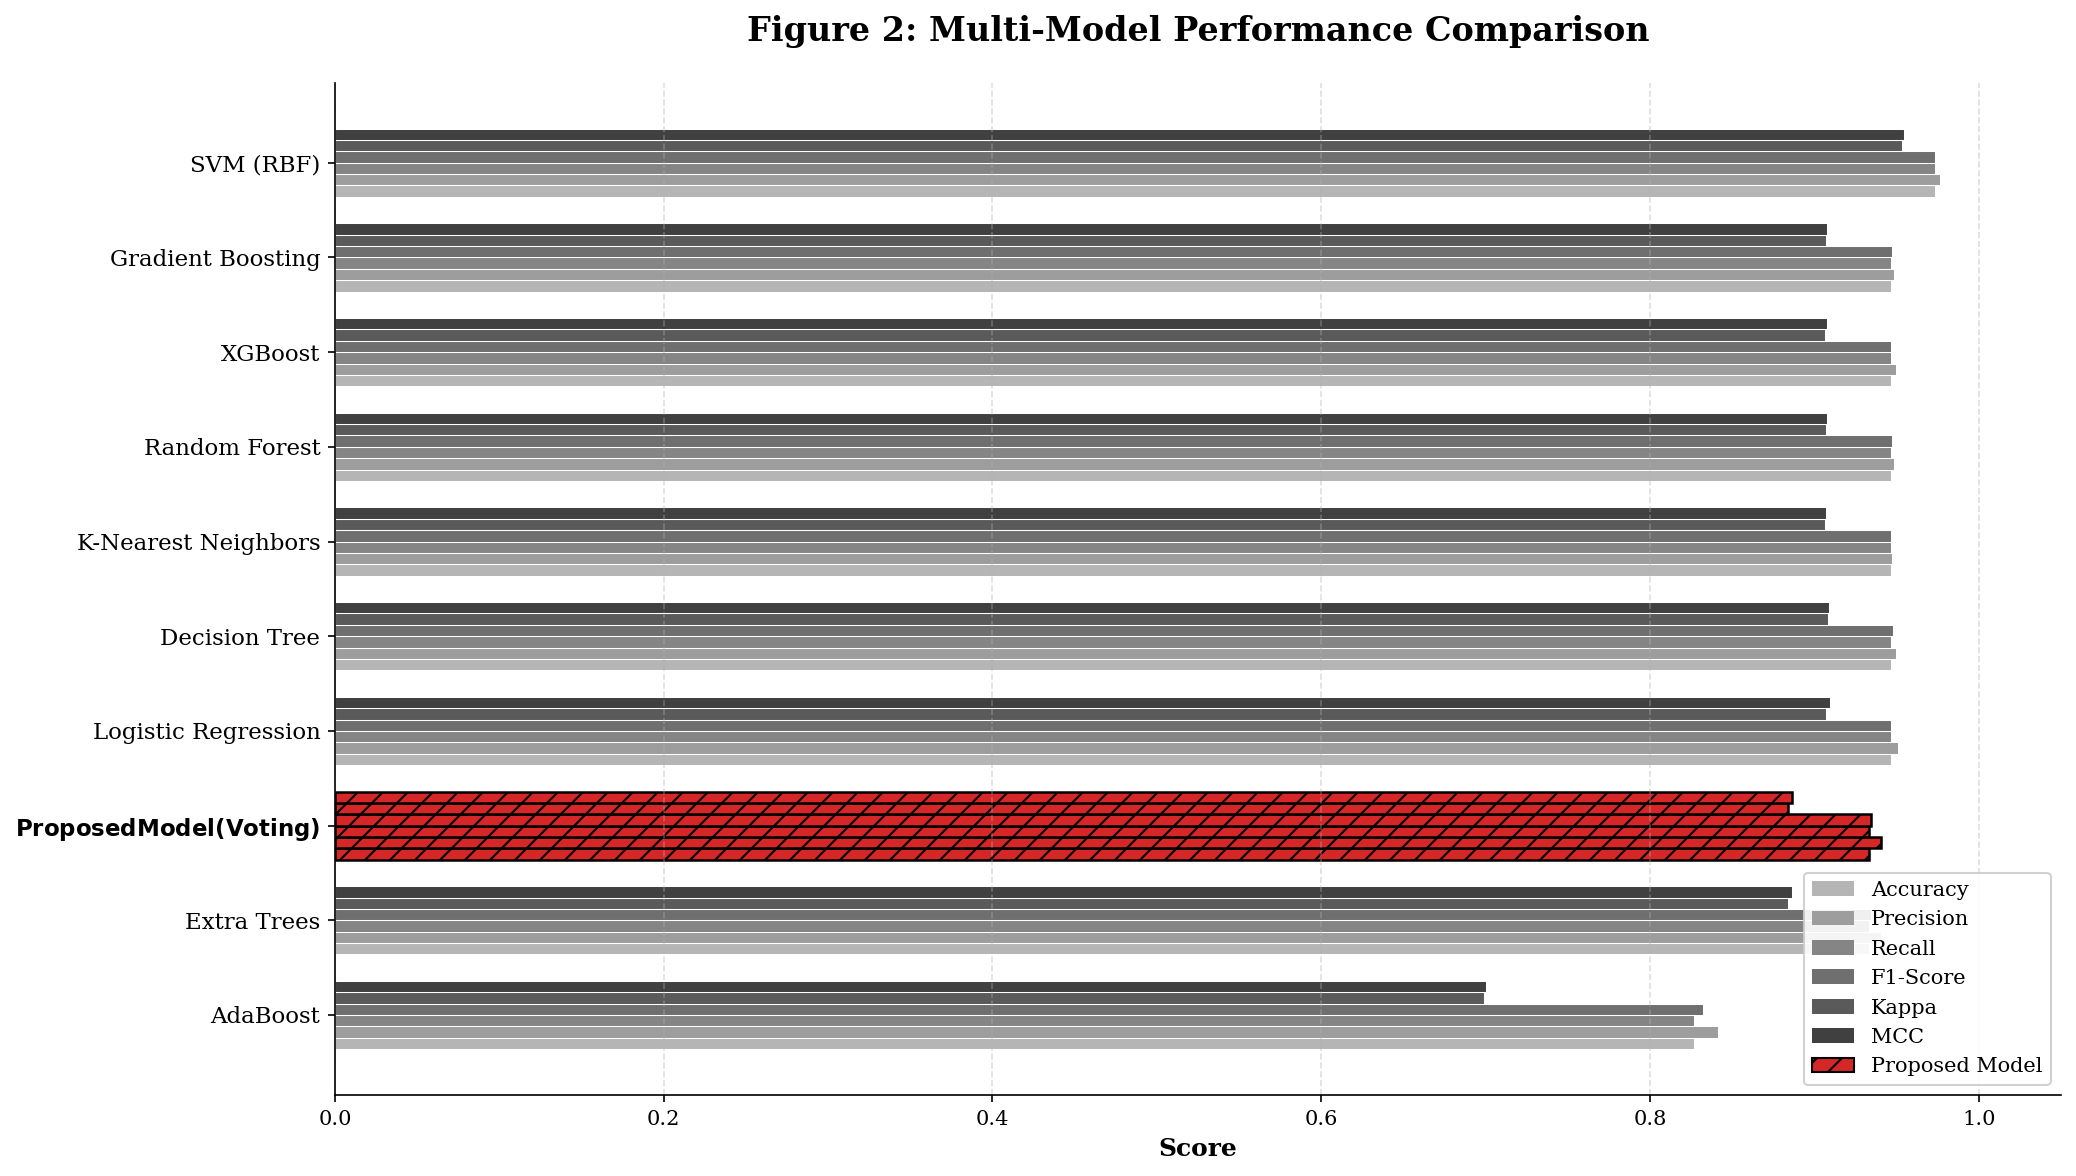

In [30]:
# ============================================================
# Figure 2: Grouped Bar Chart — Model Performance Comparison
# ============================================================
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Kappa', 'MCC']
plot_df = results_df[metrics_to_plot].sort_values('Accuracy', ascending=True)

# Generate a muted color palette for baselines
baseline_colors = plt.cm.Greys(np.linspace(0.4, 0.8, len(metrics_to_plot)))

fig, ax = plt.subplots(figsize=(14, 8))
bar_width = 0.12
x = np.arange(len(plot_df))

for i, metric in enumerate(metrics_to_plot):
    # Determine colors for each bar: crimson for proposed, gray for others
    bar_colors = ['#d62728' if 'Proposed' in m else baseline_colors[i] for m in plot_df.index]
    
    bars = ax.barh(x + i * bar_width, plot_df[metric], bar_width,
                   label=metric, color=bar_colors, edgecolor='white', linewidth=0.5)
    
    # Add hatching to the proposed model bars to make them pop even more
    for bar, model_name in zip(bars, plot_df.index):
        if 'Proposed' in model_name:
            bar.set_hatch('//')
            bar.set_edgecolor('black')
            bar.set_linewidth(1.2)

ax.set_yticks(x + bar_width * (len(metrics_to_plot) - 1) / 2)
# Make the proposed model label bold
yticklabels = [f"$\\bf{{{m}}}$" if 'Proposed' in m else m for m in plot_df.index]
ax.set_yticklabels(yticklabels, fontsize=11)

ax.set_xlabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Figure 2: Multi-Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)

# Custom legend to just show metrics, not colors (since colors depend on proposed vs baseline)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=baseline_colors[i], label=metric) for i, metric in enumerate(metrics_to_plot)]
legend_elements.append(Patch(facecolor='#d62728', hatch='//', edgecolor='black', label='Proposed Model'))
ax.legend(handles=legend_elements, loc='lower right', framealpha=0.9, fontsize=10)

ax.set_xlim(0, 1.05)
ax.grid(axis='x', alpha=0.4, linestyle='--')

# Remove top and right spines for a cleaner, research-like look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Figure 3: ROC Curves — Per-Class (One-vs-Rest) for All Models

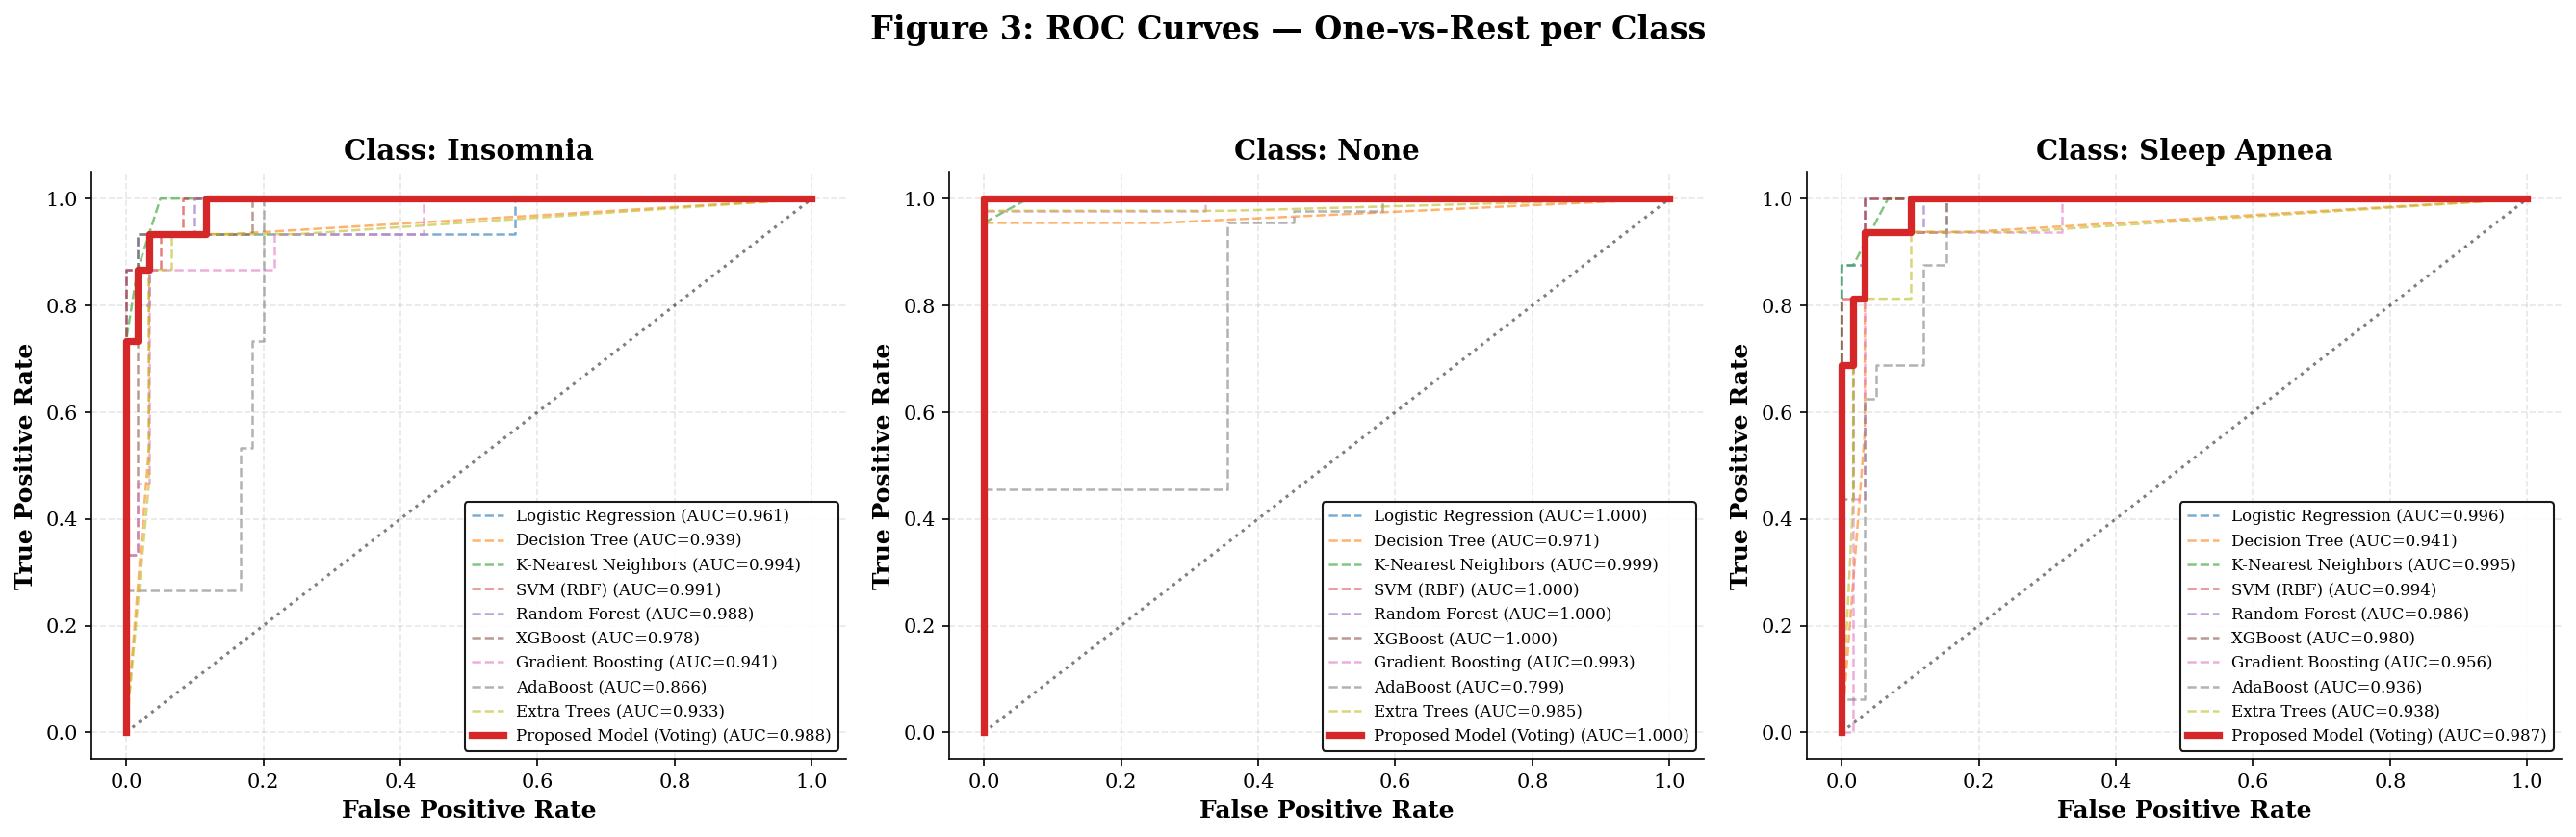

In [15]:
# ============================================================
# Figure 3: Multi-Model ROC Curves (per class, One-vs-Rest)
# ============================================================
from sklearn.preprocessing import label_binarize

n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 5.5))
colors_roc = plt.cm.tab10(np.linspace(0, 1, len(results)))

for cls_idx in range(n_classes):
    ax = axes[cls_idx]
    for (name, res), color in zip(results.items(), colors_roc):
        proba = res['Probabilities']
        if proba is None:
            continue
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], proba[:, cls_idx])
        roc_auc_val = auc(fpr, tpr)
        
        is_proposed = 'Proposed' in name
        lw = 3.5 if is_proposed else 1.2
        ls = '-' if is_proposed else '--'
        c = '#d62728' if is_proposed else color
        z = 10 if is_proposed else 2
        alpha = 1.0 if is_proposed else 0.6
        
        ax.plot(fpr, tpr, color=c, lw=lw, linestyle=ls, zorder=z, alpha=alpha,
                label=f'{name} (AUC={roc_auc_val:.3f})')
                
    ax.plot([0, 1], [0, 1], 'k:', lw=1.5, alpha=0.5)
    ax.set_xlabel('False Positive Rate', fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontweight='bold')
    ax.set_title(f'Class: {le.classes_[cls_idx]}', fontweight='bold')
    ax.legend(fontsize=8, loc='lower right', framealpha=0.9, edgecolor='black')
    ax.grid(alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Figure 3: ROC Curves \u2014 One-vs-Rest per Class', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Figure 4: Precision–Recall Curves per Class

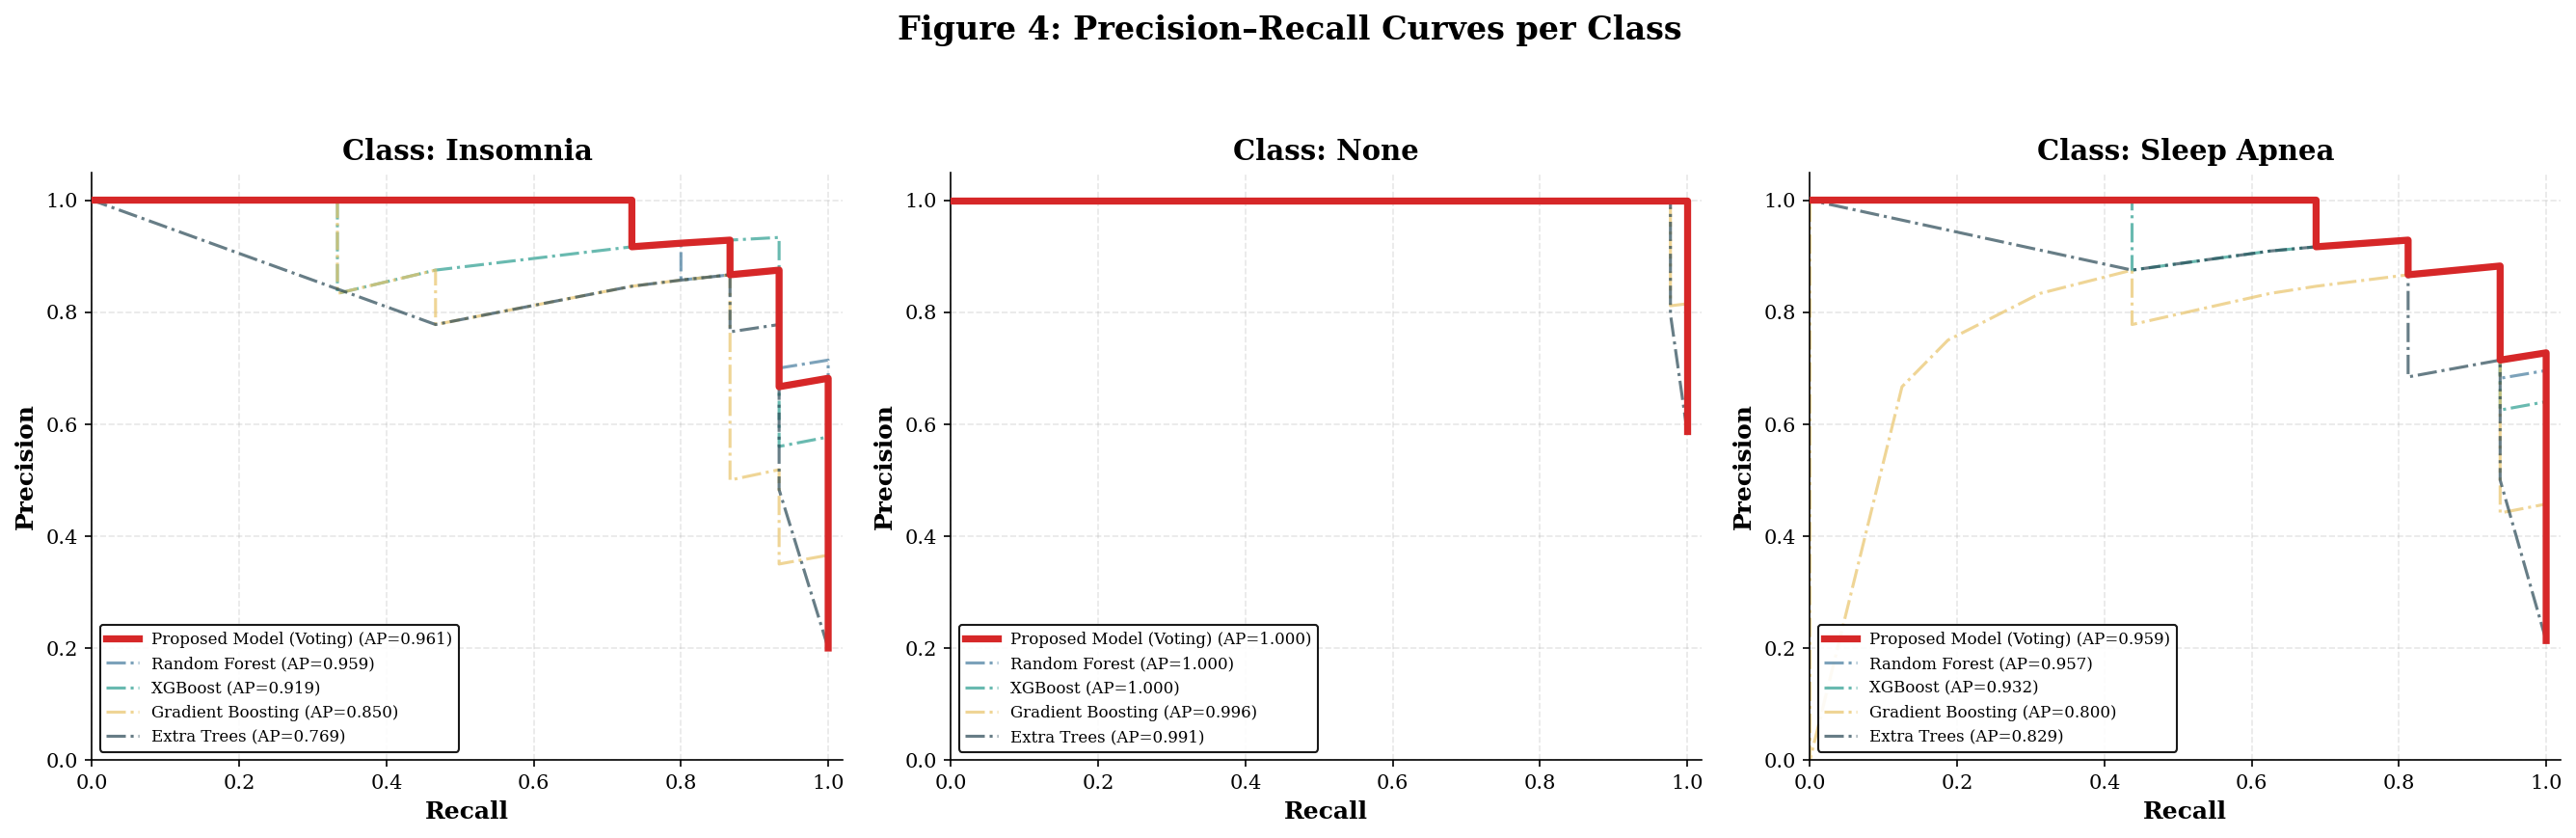

In [16]:
# ============================================================
# Figure 4: Precision-Recall Curves (Proposed vs top models)
# ============================================================
top_models_for_pr = ['Proposed Model (Voting)', 'Random Forest', 'XGBoost',
                     'Gradient Boosting', 'Extra Trees']

fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 5.5))
colors_pr = ['#d62728', '#457b9d', '#2a9d8f', '#e9c46a', '#264653']

for cls_idx in range(n_classes):
    ax = axes[cls_idx]
    for name, color in zip(top_models_for_pr, colors_pr):
        proba = results[name]['Probabilities']
        if proba is None:
            continue
        precision_vals, recall_vals, _ = precision_recall_curve(
            y_test_bin[:, cls_idx], proba[:, cls_idx])
        ap = average_precision_score(y_test_bin[:, cls_idx], proba[:, cls_idx])
        
        is_proposed = 'Proposed' in name
        lw = 3.5 if is_proposed else 1.5
        c = '#d62728' if is_proposed else color
        z = 10 if is_proposed else 2
        alpha = 1.0 if is_proposed else 0.7
        ls = '-' if is_proposed else '-.'
        
        ax.plot(recall_vals, precision_vals, color=c, lw=lw, zorder=z, alpha=alpha, linestyle=ls,
                label=f'{name} (AP={ap:.3f})')
                
    ax.set_xlabel('Recall', fontweight='bold')
    ax.set_ylabel('Precision', fontweight='bold')
    ax.set_title(f'Class: {le.classes_[cls_idx]}', fontweight='bold')
    ax.legend(fontsize=8, loc='lower left', framealpha=0.9, edgecolor='black')
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_xlim([0, 1.02])
    ax.set_ylim([0, 1.05])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Figure 4: Precision\u2013Recall Curves per Class', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Figure 5: Learning Curves — Voting vs Individual Estimators

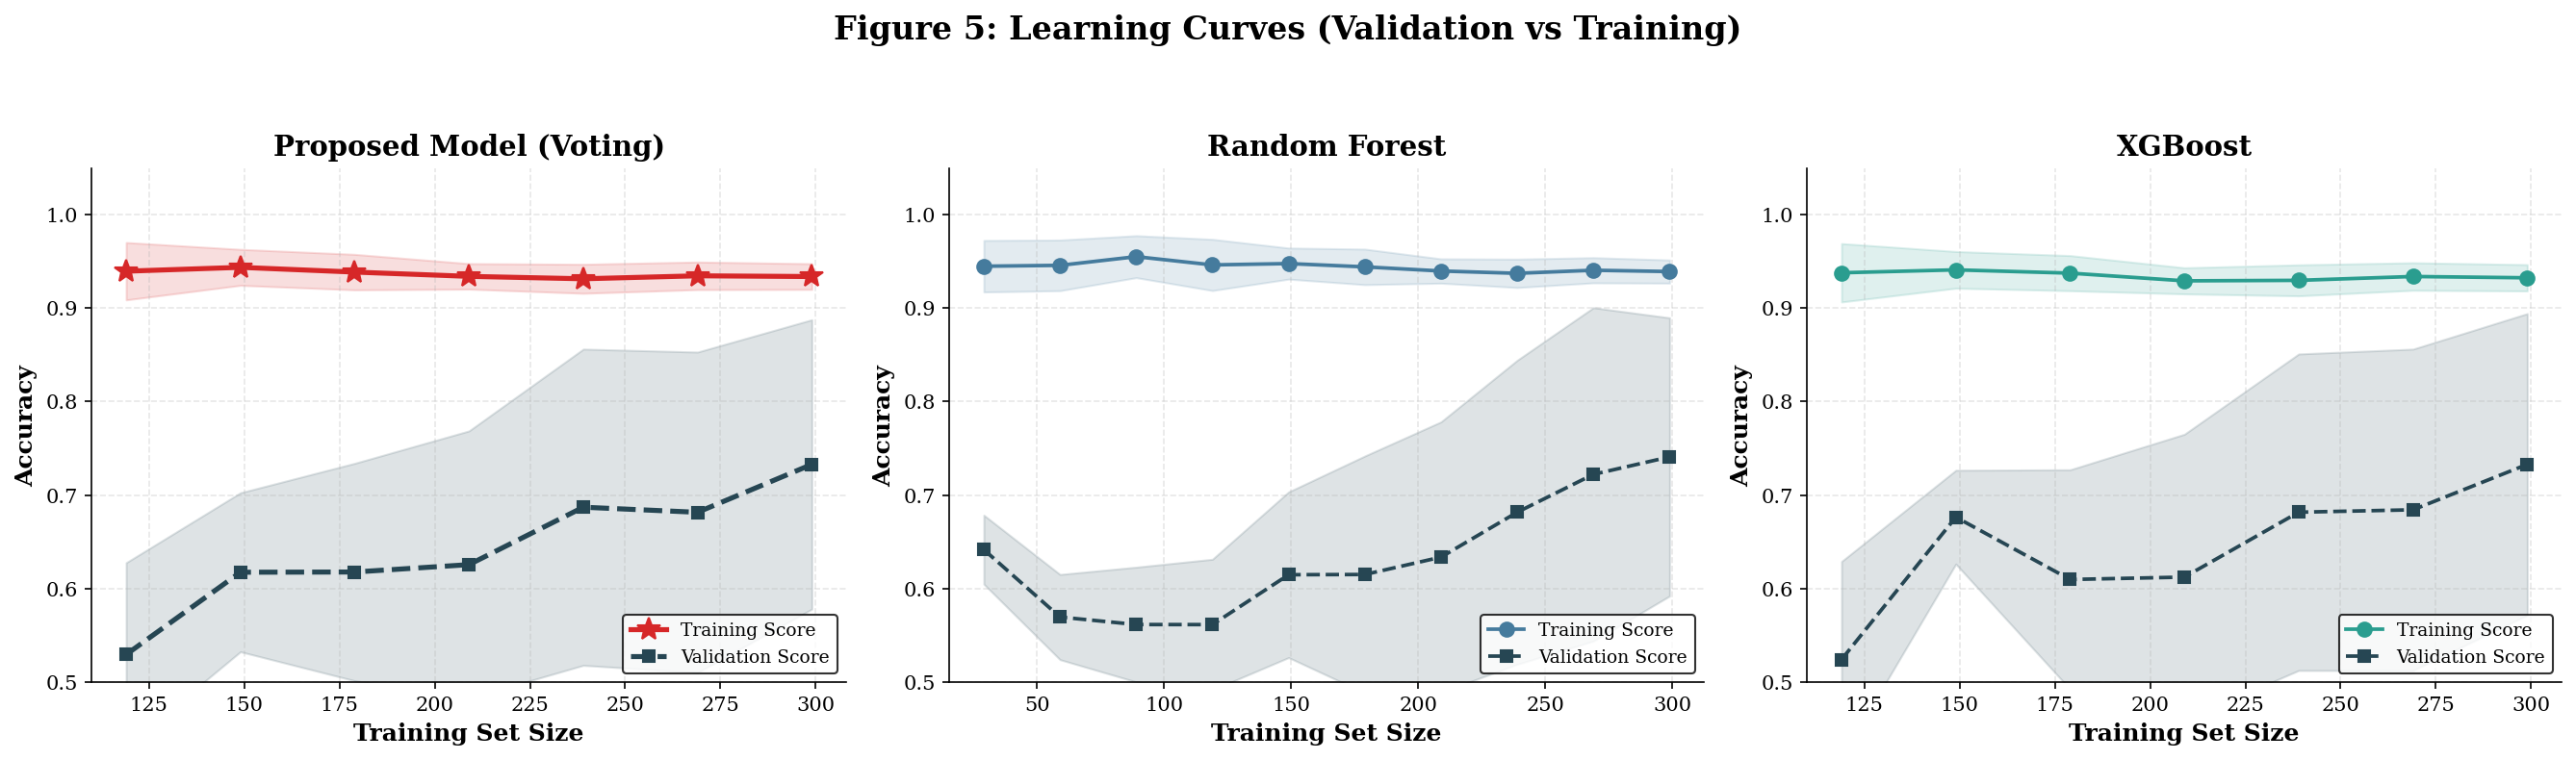

In [17]:
# ============================================================
# Figure 5: Learning Curves
# ============================================================
lc_models = {
    'Proposed Model (Voting)': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', VotingClassifier(
            estimators=[('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
                        ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.05,
                                              max_depth=5, eval_metric='mlogloss',
                                              random_state=42))],
            voting='soft', n_jobs=None))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.05,
                                     max_depth=5, eval_metric='mlogloss',
                                     random_state=42))
    ]),
}

fig, axes = plt.subplots(1, len(lc_models), figsize=(6 * len(lc_models), 5))
colors_lc = ['#d62728', '#457b9d', '#2a9d8f']

for ax, (name, model), color in zip(axes, lc_models.items(), colors_lc):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y_encoded, cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=42, n_jobs=None)

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    is_proposed = 'Proposed' in name
    marker_style = '*' if is_proposed else 'o'
    ms = 12 if is_proposed else 7
    lw = 2.5 if is_proposed else 1.8

    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color=color)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='#264653')
    ax.plot(train_sizes, train_mean, marker=marker_style, markersize=ms, color=color, lw=lw, label='Training Score')
    ax.plot(train_sizes, val_mean, 's--', color='#264653', lw=lw, markersize=6, label='Validation Score')
    
    ax.set_xlabel('Training Set Size', fontweight='bold')
    ax.set_ylabel('Accuracy', fontweight='bold')
    ax.set_title(name, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9, edgecolor='black')
    ax.set_ylim([0.5, 1.05])
    ax.grid(alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Figure 5: Learning Curves (Validation vs Training)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Figure 6: Stratified K-Fold Cross-Validation Box Plot

LR              | Mean=0.9087 +/- 0.0391
DT              | Mean=0.8983 +/- 0.0337
KNN             | Mean=0.8872 +/- 0.0484
SVM             | Mean=0.9087 +/- 0.0426
RF              | Mean=0.9115 +/- 0.0401
XGB             | Mean=0.9142 +/- 0.0396
GB              | Mean=0.9141 +/- 0.0463
AdaB            | Mean=0.7886 +/- 0.0518
ET              | Mean=0.9035 +/- 0.0423
Proposed Model  | Mean=0.9142 +/- 0.0396


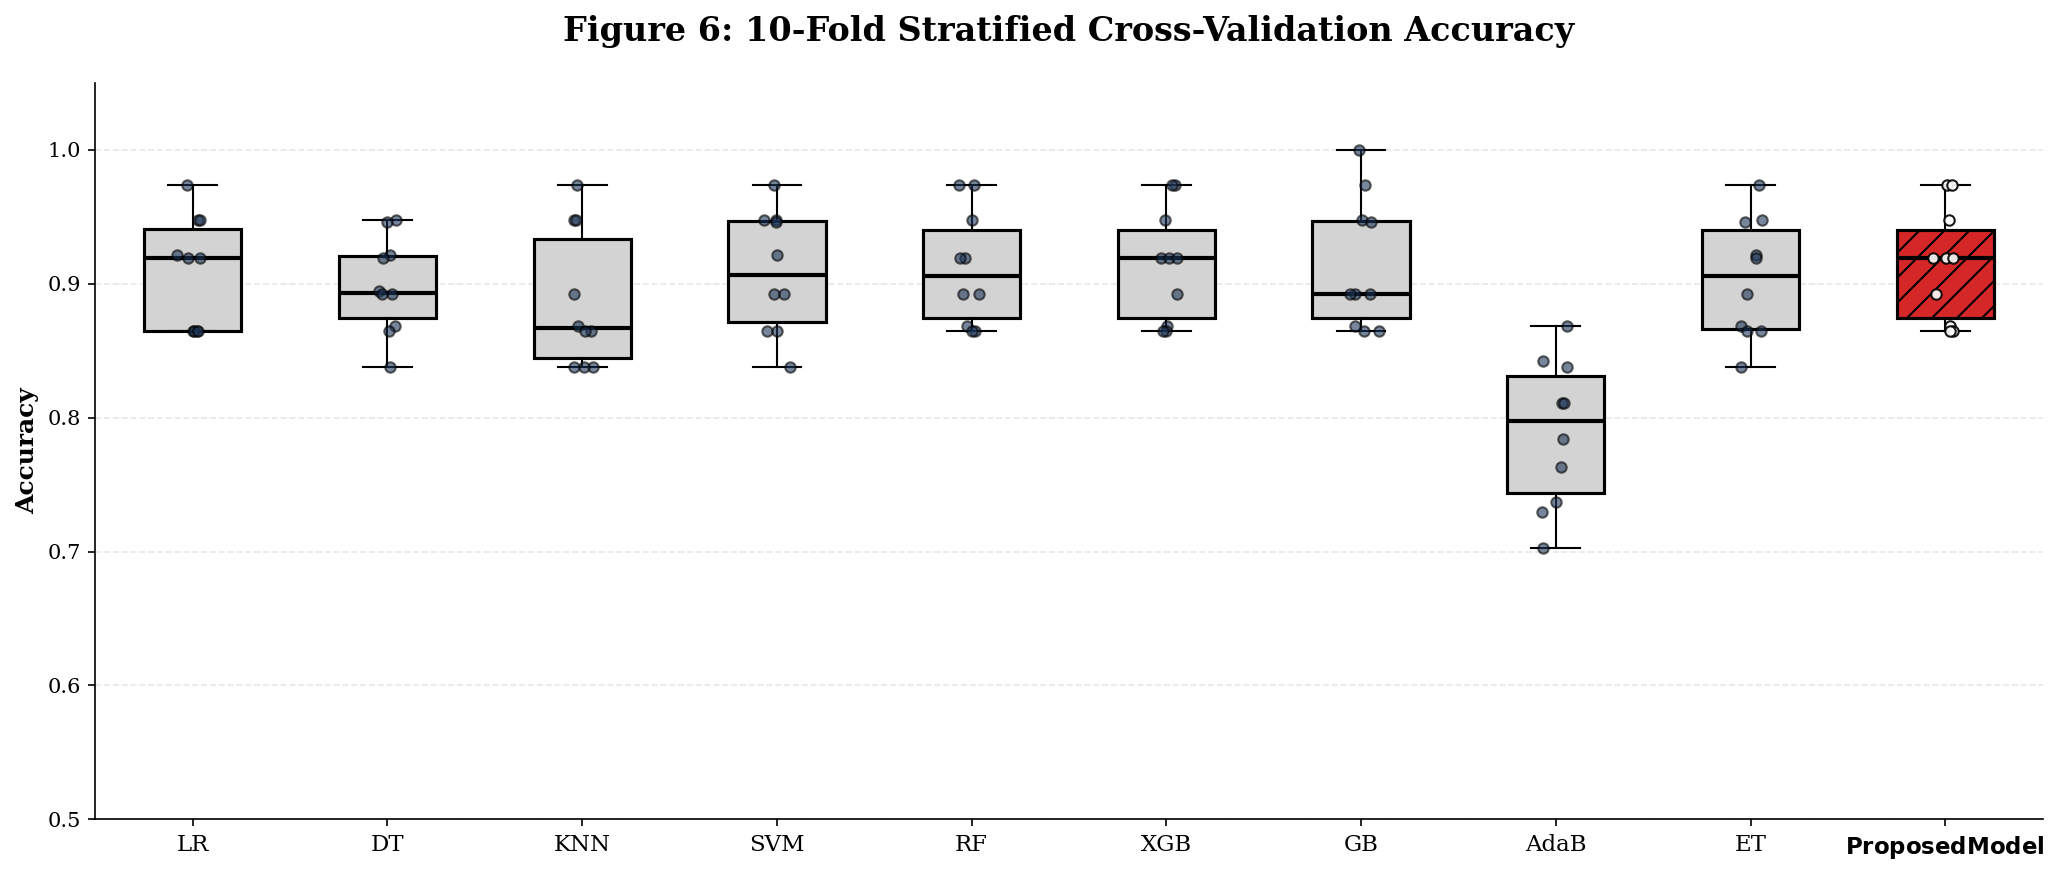

In [18]:
# ============================================================
# Figure 6: Cross-Validation Box Plot (10-fold)
# ============================================================
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_models = {
    'LR': Pipeline([('p', preprocessor), ('c', LogisticRegression(max_iter=4000, random_state=42))]),
    'DT': Pipeline([('p', preprocessor), ('c', DecisionTreeClassifier(random_state=42))]),
    'KNN': Pipeline([('p', preprocessor), ('c', KNeighborsClassifier())]),
    'SVM': Pipeline([('p', preprocessor), ('c', SVC(probability=True, random_state=42))]),
    'RF': Pipeline([('p', preprocessor), ('c', RandomForestClassifier(n_estimators=200, random_state=42))]),
    'XGB': Pipeline([('p', preprocessor), ('c', XGBClassifier(n_estimators=200, learning_rate=0.05,
                                                               max_depth=5, eval_metric='mlogloss',
                                                               random_state=42))]),
    'GB': Pipeline([('p', preprocessor), ('c', GradientBoostingClassifier(n_estimators=200, random_state=42))]),
    'AdaB': Pipeline([('p', preprocessor), ('c', AdaBoostClassifier(n_estimators=200, random_state=42))]),
    'ET': Pipeline([('p', preprocessor), ('c', ExtraTreesClassifier(n_estimators=200, random_state=42))]),
    'Proposed Model': Pipeline([('p', preprocessor),
                        ('c', VotingClassifier(
                            estimators=[('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
                                        ('xgb', XGBClassifier(n_estimators=200, learning_rate=0.05,
                                                              max_depth=5, eval_metric='mlogloss',
                                                              random_state=42))],
                            voting='soft', n_jobs=None))]),
}

cv_scores_all = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X, y_encoded, cv=cv, scoring='accuracy', n_jobs=None)
    cv_scores_all[name] = scores
    print(f"{name:15s} | Mean={scores.mean():.4f} +/- {scores.std():.4f}")

fig, ax = plt.subplots(figsize=(14, 6))
box_data = [cv_scores_all[k] for k in cv_scores_all]
bp = ax.boxplot(box_data, labels=cv_scores_all.keys(), patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'))

# Highlight Proposed Model in crimson, others in light gray
box_colors = ['#d3d3d3'] * (len(cv_models) - 1) + ['#d62728']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)
    if color == '#d62728':
        patch.set_hatch('//')

# Overlay individual fold scores as scatter
for i, (name, scores) in enumerate(cv_scores_all.items()):
    jitter = np.random.normal(0, 0.04, size=len(scores))
    scatter_color = '#ffffff' if 'Proposed' in name else '#1d3557'
    ax.scatter(np.full_like(scores, i + 1) + jitter, scores,
              alpha=0.9 if 'Proposed' in name else 0.6, s=25, color=scatter_color, edgecolor='black', zorder=3)

# Bold the labels for the proposed model
xticklabels = [f"$\\bf{{{m}}}$" if 'Proposed' in m else m for m in cv_models.keys()]
ax.set_xticklabels(xticklabels, fontsize=11)

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Figure 6: 10-Fold Stratified Cross-Validation Accuracy', fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0.5, 1.05])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Figure 7: Ground-Truth vs Model Output — Prediction Curves (First 24 Test Steps)

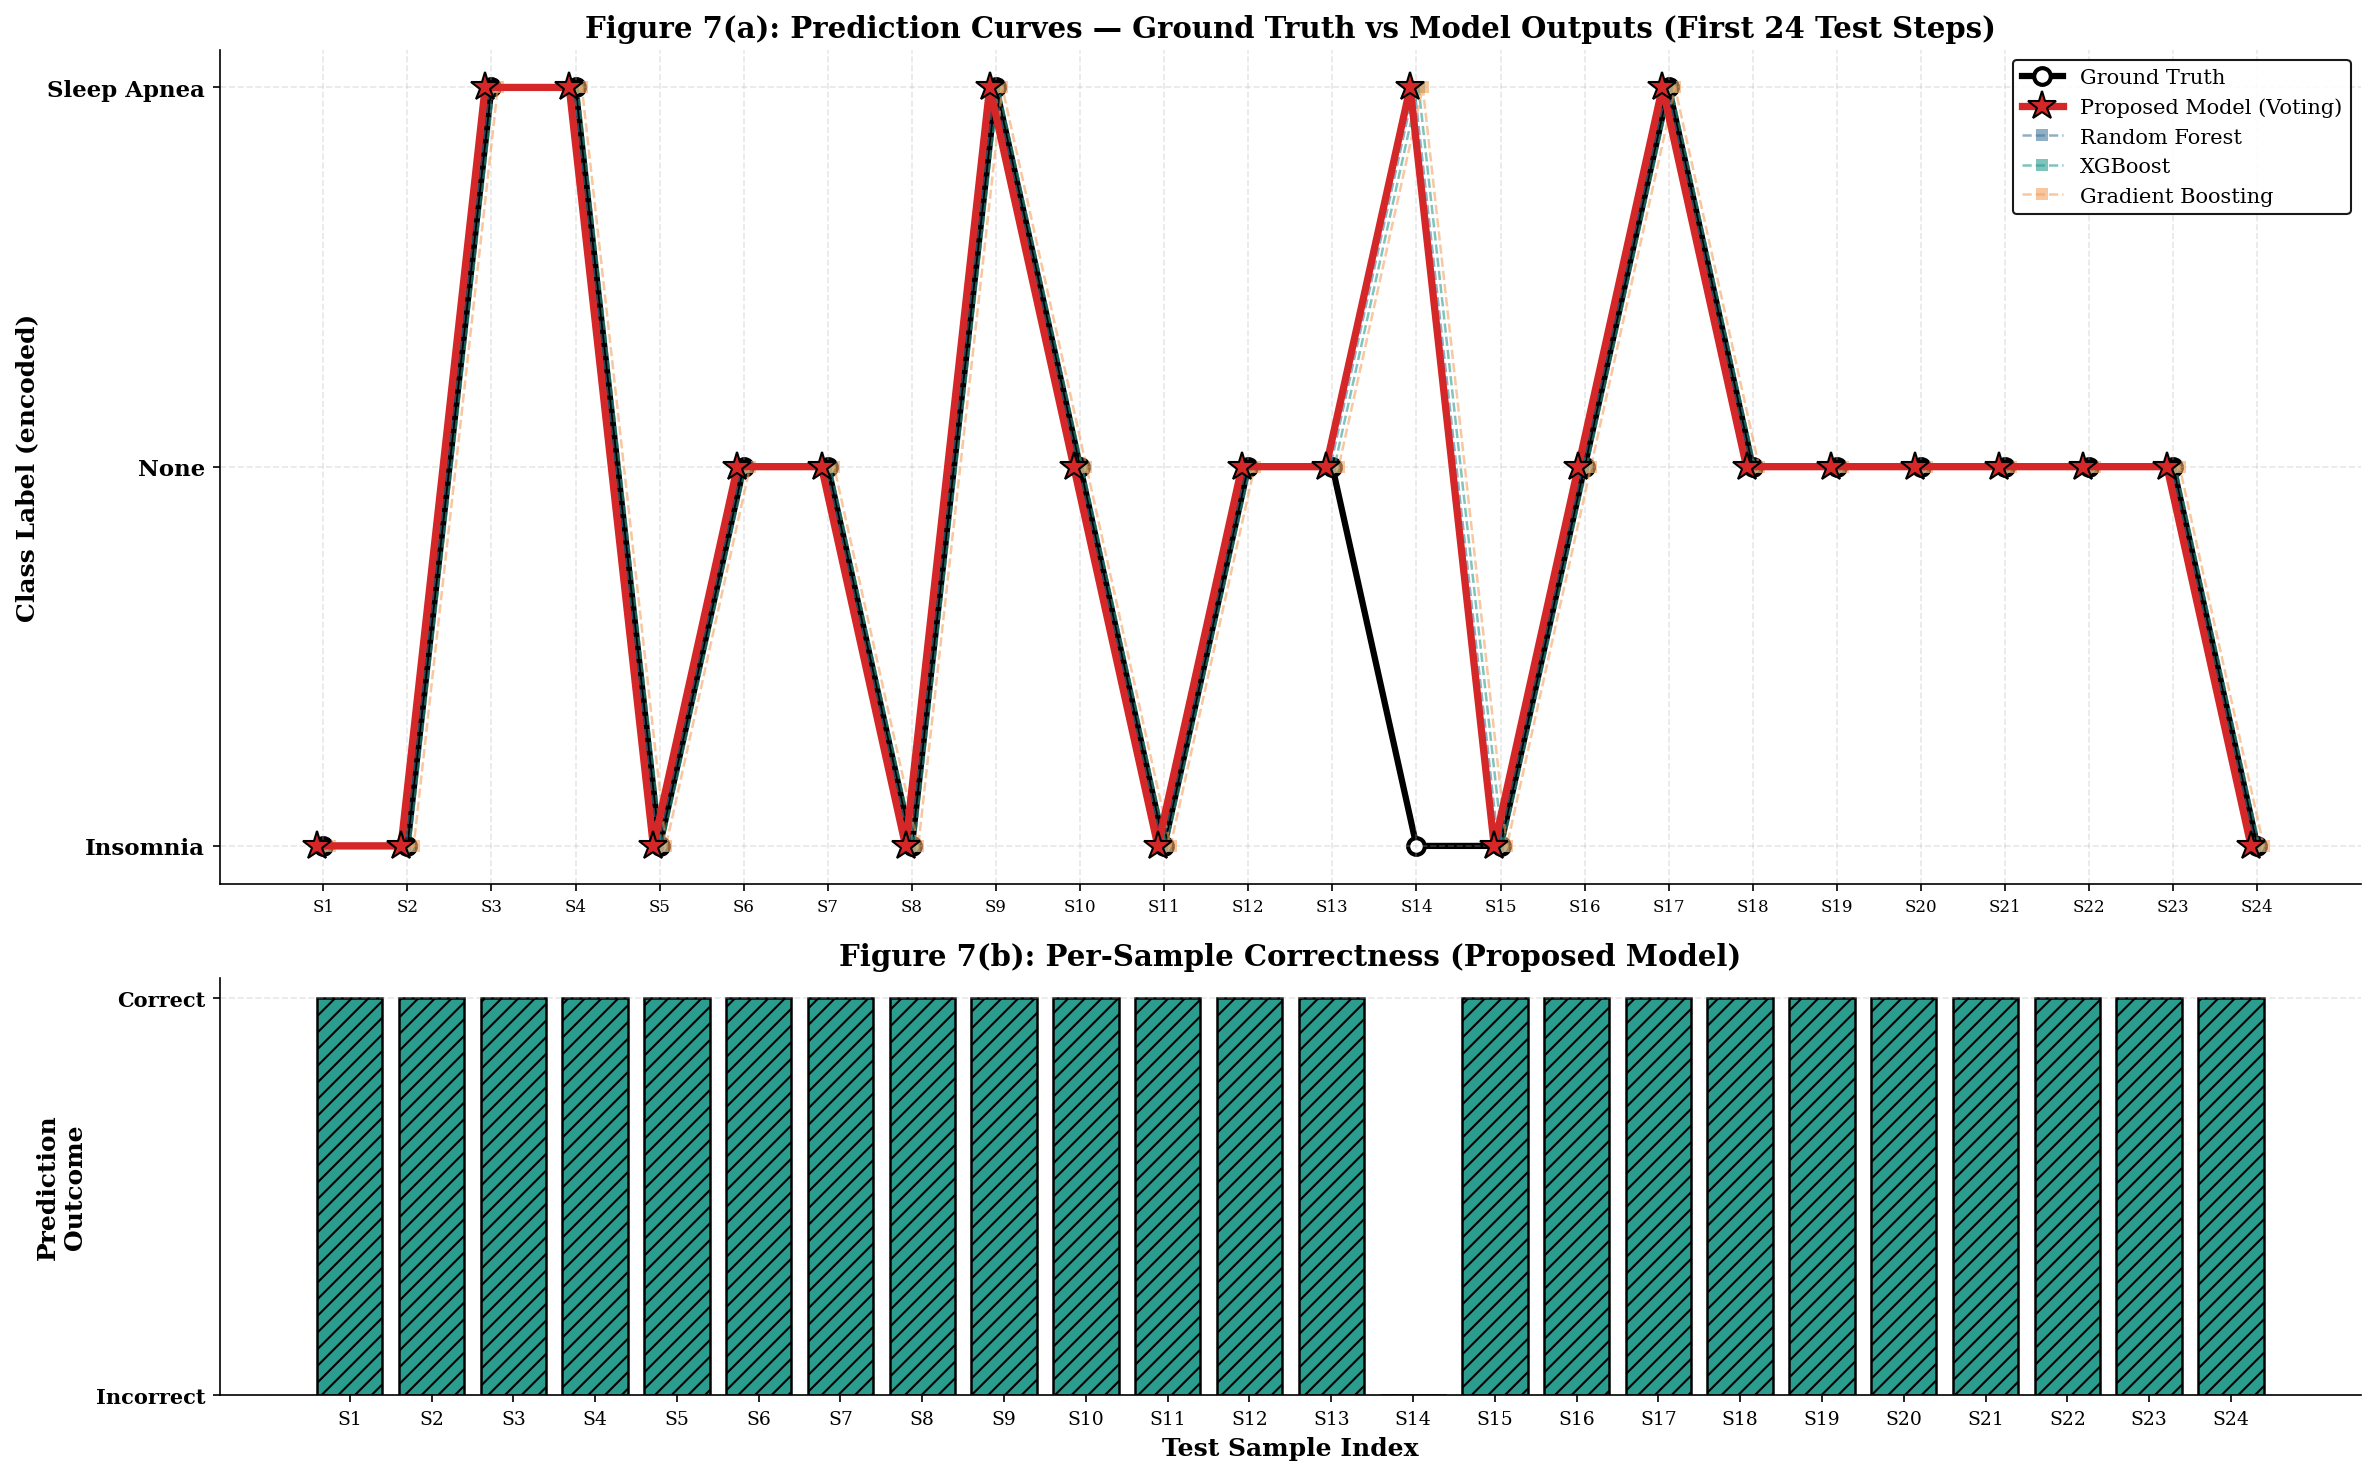


Proposed Model accuracy on first 24 samples: 95.8%


In [31]:
# ============================================================
# Figure 7: Ground-Truth vs Model Output (first 24 test steps)
# ============================================================
n_steps = min(24, len(y_test))
step_indices = np.arange(n_steps)

# Get predictions from top models for the first 24 test samples
models_to_compare = ['Proposed Model (Voting)', 'Random Forest', 'XGBoost', 'Gradient Boosting']
colors_pred = ['#d62728', '#457b9d', '#2a9d8f', '#f4a261']

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2, 1]})

# Top panel: Prediction curves
ax = axes[0]
ax.plot(step_indices, y_test[:n_steps], 'ko-', markersize=8, lw=3,
        label='Ground Truth', zorder=1, markerfacecolor='white', markeredgewidth=2)

for name, color in zip(models_to_compare, colors_pred):
    preds = results[name]['Predictions'][:n_steps]
    offset = 0.05 * (models_to_compare.index(name) - 1.5)  # slight offset for visibility
    
    is_proposed = 'Proposed' in name
    c = '#d62728' if is_proposed else color
    lw = 3.5 if is_proposed else 1.2
    ms = 14 if is_proposed else 6
    marker = '*' if is_proposed else 's'
    z = 10 if is_proposed else 2
    alpha = 1.0 if is_proposed else 0.6
    ls = '-' if is_proposed else '--'
    
    ax.plot(step_indices + offset, preds, marker, linestyle=ls, color=c, markersize=ms, lw=lw,
            label=name, alpha=alpha, zorder=z, markeredgecolor='black' if is_proposed else 'none')

ax.set_ylabel('Class Label (encoded)', fontsize=12, fontweight='bold')
ax.set_title('Figure 7(a): Prediction Curves \u2014 Ground Truth vs Model Outputs (First 24 Test Steps)',
             fontsize=14, fontweight='bold')
ax.set_xticks(step_indices)
ax.set_xticklabels([f'S{i+1}' for i in step_indices], fontsize=8)
ax.set_yticks(np.arange(n_classes))
ax.set_yticklabels(le.classes_, fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=10, framealpha=0.9, edgecolor='black')
ax.grid(alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Bottom panel: Error (correct/incorrect) for Voting model
ax2 = axes[1]
voting_preds = results['Proposed Model (Voting)']['Predictions'][:n_steps]
correct = (voting_preds == y_test[:n_steps]).astype(int)
bar_colors = ['#2a9d8f' if c == 1 else '#d62728' for c in correct]
ax2.bar(step_indices, correct, color=bar_colors, edgecolor='black', linewidth=1.2, hatch='///')
ax2.set_ylabel('Prediction\nOutcome', fontsize=12, fontweight='bold')
ax2.set_xlabel('Test Sample Index', fontsize=12, fontweight='bold')
ax2.set_title('Figure 7(b): Per-Sample Correctness (Proposed Model)',
              fontsize=14, fontweight='bold')
ax2.set_xticks(step_indices)
ax2.set_xticklabels([f'S{i+1}' for i in step_indices], fontsize=9)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Incorrect', 'Correct'], fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nProposed Model accuracy on first {n_steps} samples: {correct.mean()*100:.1f}%")

### Figure 8: Sensitivity of the Proposed Model to Histogram Bin Number

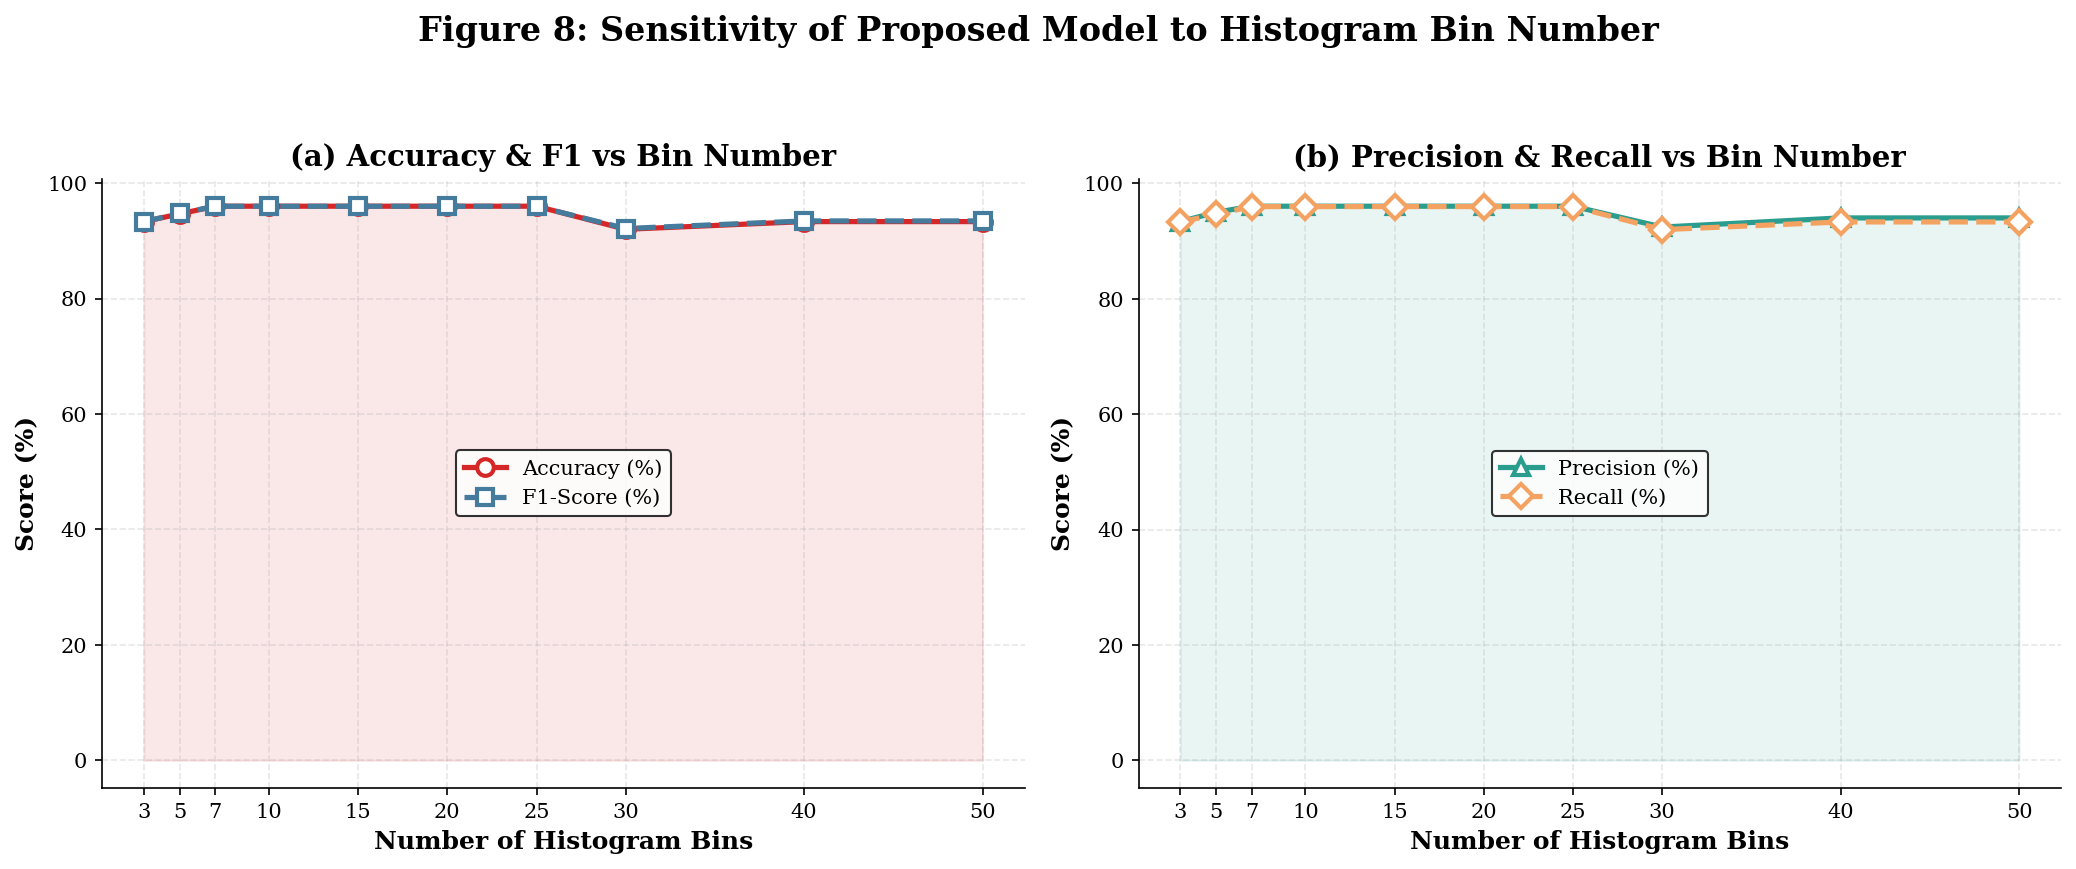

 Bins  Accuracy (%)  F1-Score (%)  Precision (%)  Recall (%)
    3     93.333333     93.333333      93.405556   93.333333
    5     94.666667     94.746901      95.015873   94.666667
    7     96.000000     95.991641      96.061625   96.000000
   10     96.000000     95.991641      96.061625   96.000000
   15     96.000000     95.991641      96.061625   96.000000
   20     96.000000     95.991641      96.061625   96.000000
   25     96.000000     95.991641      96.061625   96.000000
   30     92.000000     92.134810      92.449673   92.000000
   40     93.333333     93.450923      94.031746   93.333333
   50     93.333333     93.450923      94.031746   93.333333


In [20]:
# ============================================================
# Figure 8: Sensitivity to Histogram Bin Number
# ============================================================
# This figure analyses how the number of histogram bins used to
# discretise continuous features affects the Voting Classifier's
# performance (accuracy, F1-score) on the sleep-disorder dataset.

from sklearn.preprocessing import KBinsDiscretizer

bin_range = [3, 5, 7, 10, 15, 20, 25, 30, 40, 50]
acc_by_bins = []
f1_by_bins = []
prec_by_bins = []
rec_by_bins = []

for n_bins in bin_range:
    # Build a modified preprocessor that uses histogram-based binning
    disc_preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('binner', KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')),
                ('scaler', StandardScaler())
            ]), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ]
    )
    
    disc_voting = Pipeline([
        ('preprocessor', disc_preprocessor),
        ('classifier', VotingClassifier(
            estimators=[
                ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
                ('xgb', XGBClassifier(n_estimators=200, learning_rate=0.05,
                                      max_depth=5, eval_metric='mlogloss',
                                      random_state=42))
            ],
            voting='soft', n_jobs=None))
    ])
    
    disc_voting.fit(X_train, y_train)
    preds = disc_voting.predict(X_test)
    
    acc_by_bins.append(accuracy_score(y_test, preds))
    p, r, f, _ = precision_recall_fscore_support(y_test, preds, average='weighted')
    f1_by_bins.append(f)
    prec_by_bins.append(p)
    rec_by_bins.append(r)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) Accuracy & F1 vs Bin Number
ax = axes[0]
ax.plot(bin_range, np.array(acc_by_bins) * 100, 'o-', color='#d62728', lw=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2, label='Accuracy (%)')
ax.plot(bin_range, np.array(f1_by_bins) * 100, 's--', color='#457b9d', lw=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2, label='F1-Score (%)')
ax.fill_between(bin_range, np.array(acc_by_bins) * 100, alpha=0.1, color='#d62728')
ax.set_xlabel('Number of Histogram Bins', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
ax.set_title('(a) Accuracy & F1 vs Bin Number', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, edgecolor='black')
ax.grid(alpha=0.3, linestyle='--')
ax.set_xticks(bin_range)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (b) Precision & Recall vs Bin Number
ax2 = axes[1]
ax2.plot(bin_range, np.array(prec_by_bins) * 100, '^-', color='#2a9d8f', lw=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2, label='Precision (%)')
ax2.plot(bin_range, np.array(rec_by_bins) * 100, 'D--', color='#f4a261', lw=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2, label='Recall (%)')
ax2.fill_between(bin_range, np.array(prec_by_bins) * 100, alpha=0.1, color='#2a9d8f')
ax2.set_xlabel('Number of Histogram Bins', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
ax2.set_title('(b) Precision & Recall vs Bin Number', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, edgecolor='black')
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_xticks(bin_range)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Figure 8: Sensitivity of Proposed Model to Histogram Bin Number',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Print summary table
bin_results_df = pd.DataFrame({
    'Bins': bin_range,
    'Accuracy (%)': np.array(acc_by_bins) * 100,
    'F1-Score (%)': np.array(f1_by_bins) * 100,
    'Precision (%)': np.array(prec_by_bins) * 100,
    'Recall (%)': np.array(rec_by_bins) * 100,
})
print(bin_results_df.to_string(index=False))

### Figure 9: Effect of Histogram Bin Number on Forecasting Performance (Heatmap)

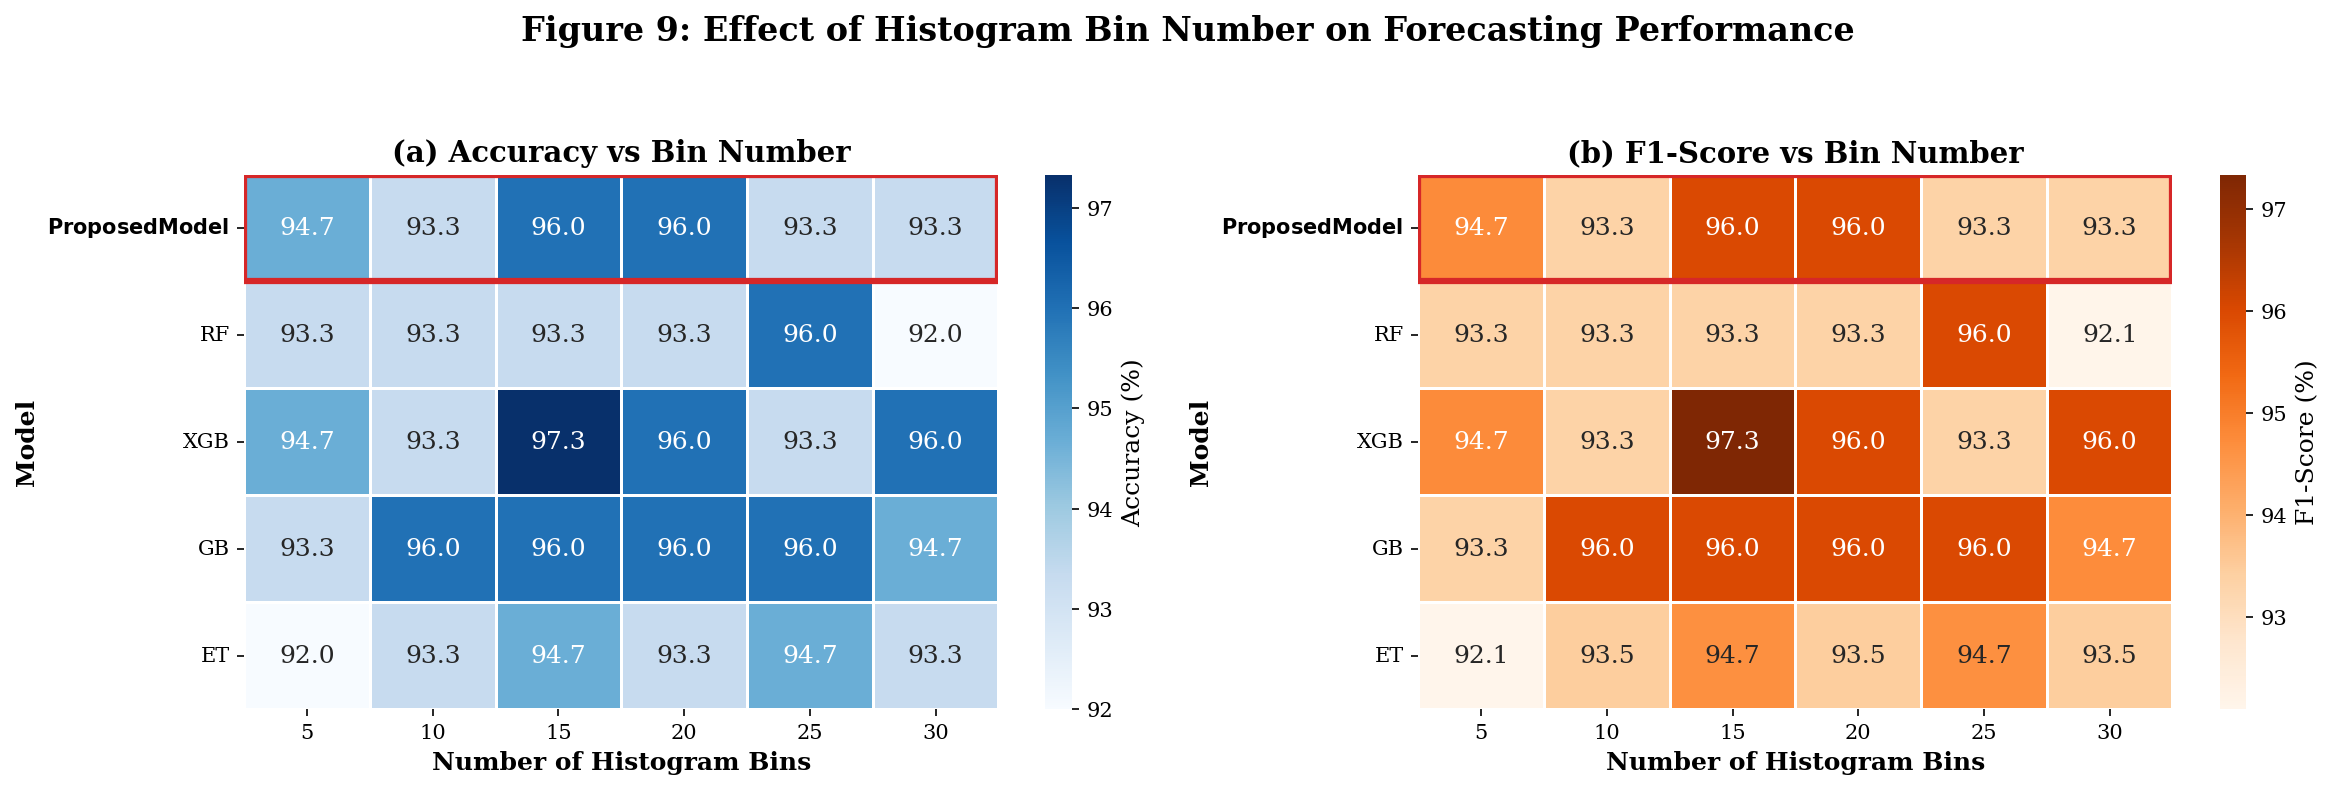

In [21]:
# ============================================================
# Figure 9: Effect of Histogram Bin Number on Forecasting
#           Performance — Heatmap across Models
# ============================================================
import matplotlib.patches as patches

bin_range_hm = [5, 10, 15, 20, 25, 30]
hm_models = {
    'Proposed Model': lambda: VotingClassifier(
        estimators=[('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
                    ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.05,
                                          max_depth=5, eval_metric='mlogloss',
                                          random_state=42))],
        voting='soft', n_jobs=None),
    'RF': lambda: RandomForestClassifier(n_estimators=100, random_state=42),
    'XGB': lambda: XGBClassifier(n_estimators=100, learning_rate=0.05,
                                  max_depth=5, eval_metric='mlogloss', random_state=42),
    'GB': lambda: GradientBoostingClassifier(n_estimators=100, random_state=42),
    'ET': lambda: ExtraTreesClassifier(n_estimators=100, random_state=42),
}

hm_accuracy = np.zeros((len(hm_models), len(bin_range_hm)))
hm_f1 = np.zeros_like(hm_accuracy)

for i, (mname, clf_factory) in enumerate(hm_models.items()):
    for j, n_bins in enumerate(bin_range_hm):
        pp = ColumnTransformer(transformers=[
            ('num', Pipeline([
                ('binner', KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')),
                ('scaler', StandardScaler())
            ]), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ])
        pipe = Pipeline([('preprocessor', pp), ('classifier', clf_factory())])
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)
        hm_accuracy[i, j] = accuracy_score(y_test, preds)
        hm_f1[i, j] = f1_score(y_test, preds, average='weighted')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Get index of Proposed Model
proposed_idx = list(hm_models.keys()).index('Proposed Model')

# Accuracy heatmap
sns.heatmap(hm_accuracy * 100, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=bin_range_hm, yticklabels=list(hm_models.keys()),
            ax=axes[0], linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Accuracy (%)'})

# Add red rectangle around Proposed Model
axes[0].add_patch(patches.Rectangle((0, proposed_idx), len(bin_range_hm), 1, 
                                    fill=False, edgecolor='#d62728', lw=3, zorder=10))

axes[0].set_xlabel('Number of Histogram Bins', fontweight='bold')
axes[0].set_ylabel('Model', fontweight='bold')
axes[0].set_title('(a) Accuracy vs Bin Number', fontweight='bold')
yticklabels = [f"$\\bf{{{m}}}$" if 'Proposed' in m else m for m in hm_models.keys()]
axes[0].set_yticklabels(yticklabels, rotation=0)

# F1 heatmap
sns.heatmap(hm_f1 * 100, annot=True, fmt='.1f', cmap='Oranges',
            xticklabels=bin_range_hm, yticklabels=list(hm_models.keys()),
            ax=axes[1], linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'F1-Score (%)'})

# Add red rectangle around Proposed Model
axes[1].add_patch(patches.Rectangle((0, proposed_idx), len(bin_range_hm), 1, 
                                    fill=False, edgecolor='#d62728', lw=3, zorder=10))

axes[1].set_xlabel('Number of Histogram Bins', fontweight='bold')
axes[1].set_ylabel('Model', fontweight='bold')
axes[1].set_title('(b) F1-Score vs Bin Number', fontweight='bold')
axes[1].set_yticklabels(yticklabels, rotation=0)

plt.suptitle('Figure 9: Effect of Histogram Bin Number on Forecasting Performance',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Figure 10: Feature Correlation Heatmap

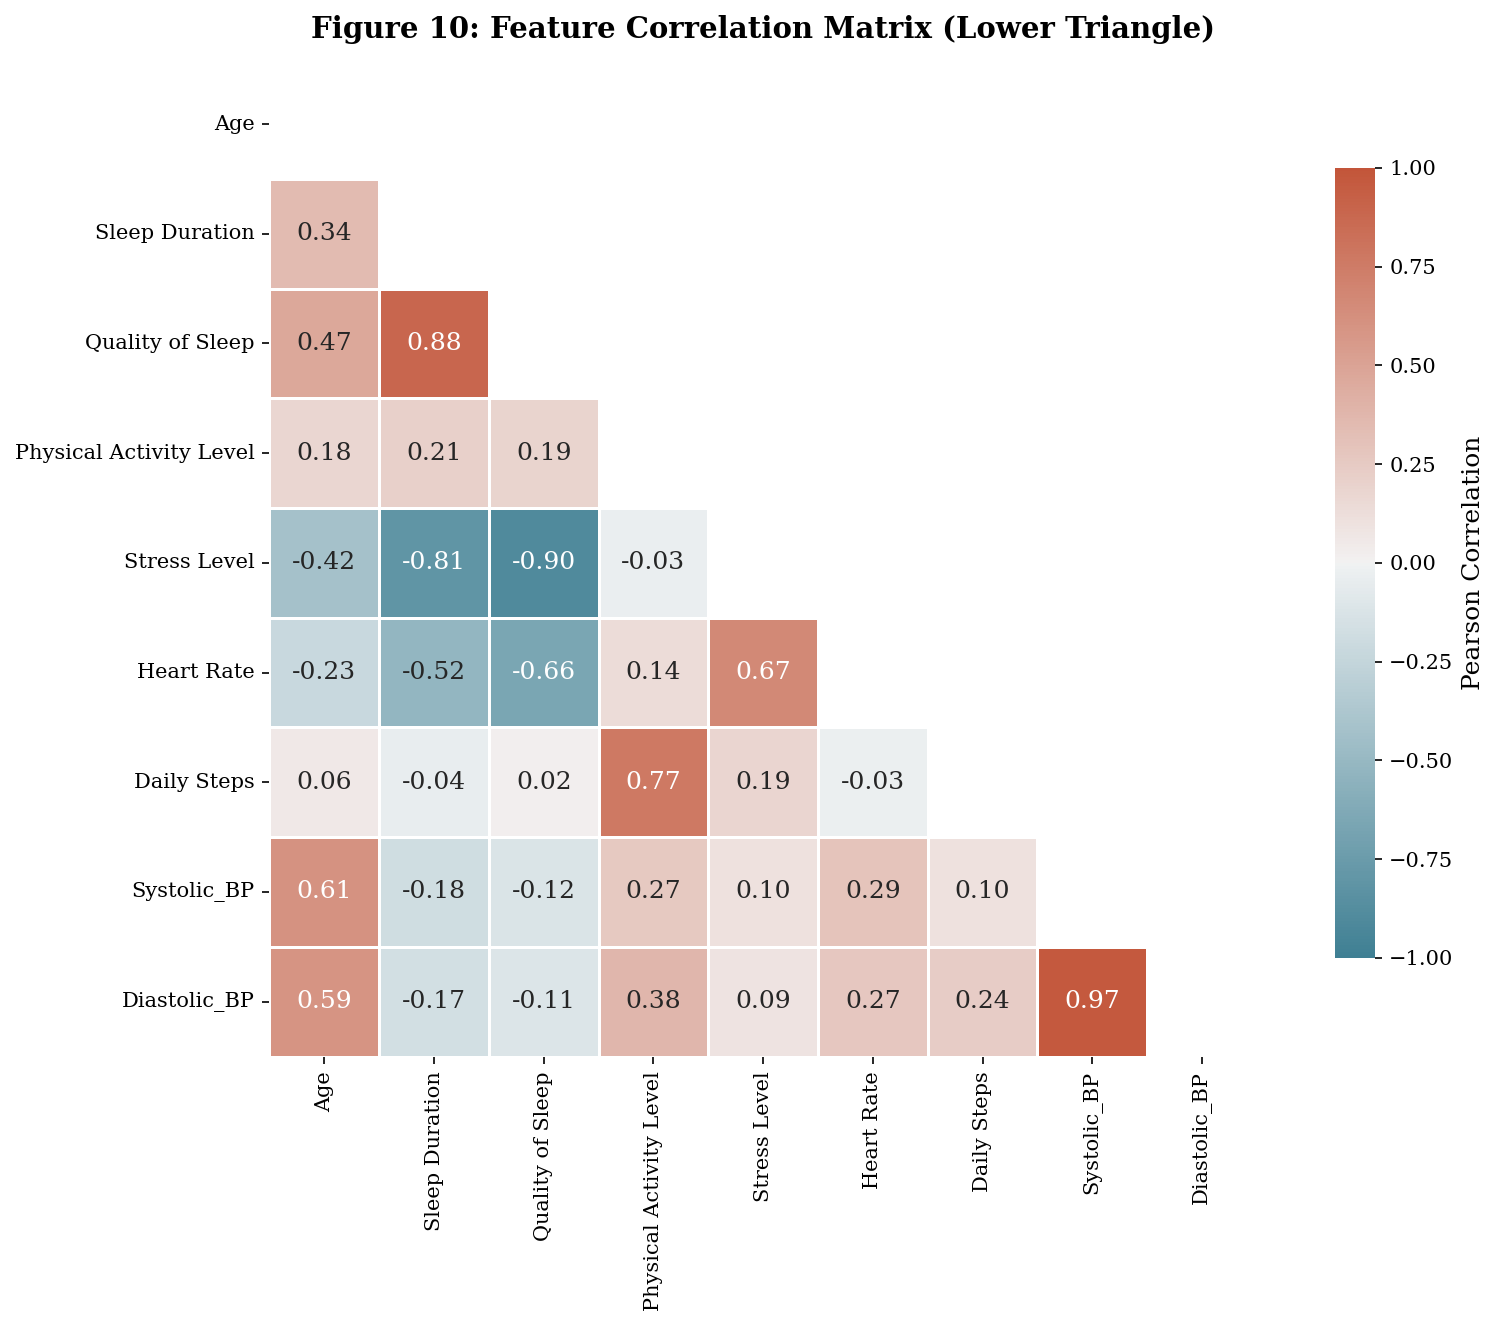

In [22]:
# ============================================================
# Figure 10: Feature Correlation Heatmap
# ============================================================
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='white',
            square=True, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'})
ax.set_title('Figure 10: Feature Correlation Matrix (Lower Triangle)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Figure 11: Class Distribution Analysis

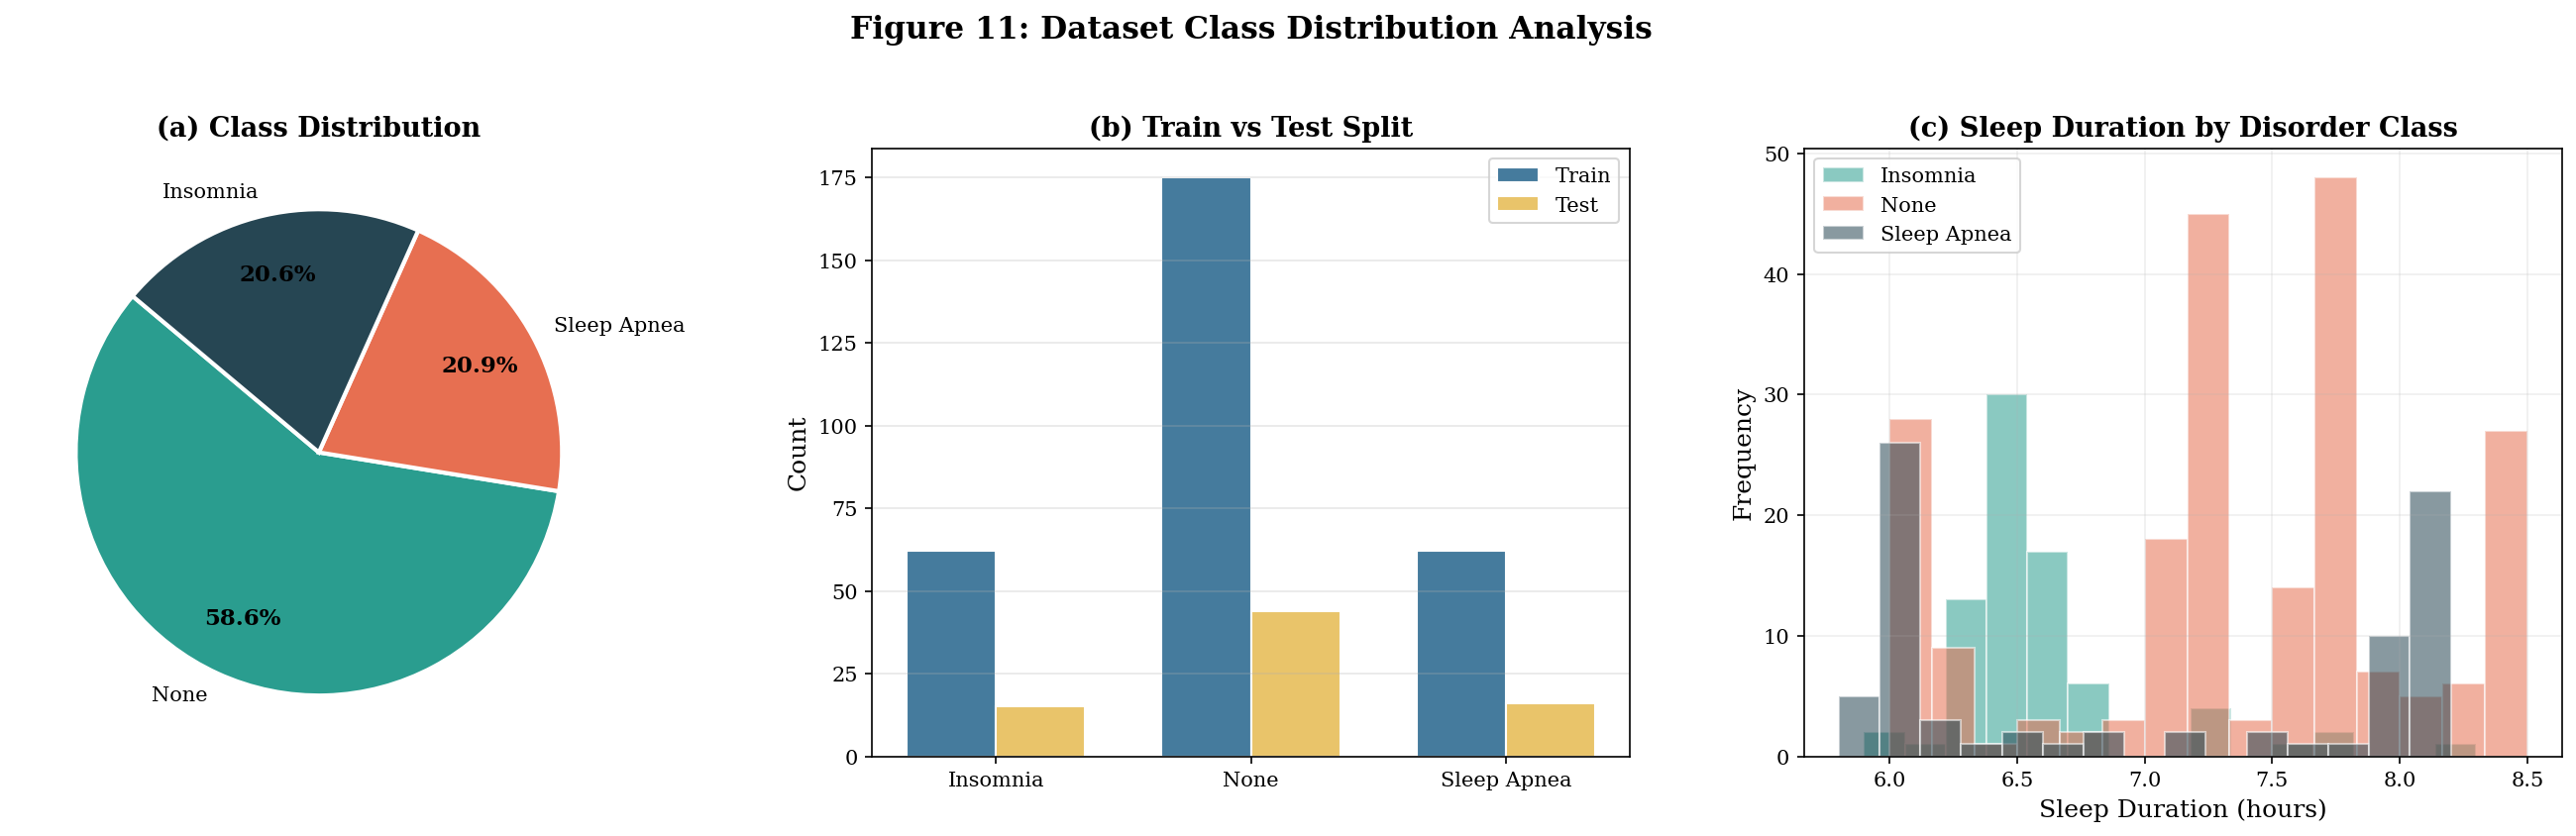

In [23]:
# ============================================================
# Figure 11: Class Distribution Analysis
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# (a) Overall class distribution
class_counts = df['Sleep Disorder'].value_counts()
colors_pie = ['#2a9d8f', '#e76f51', '#264653']
wedges, texts, autotexts = axes[0].pie(
    class_counts, labels=class_counts.index, autopct='%1.1f%%',
    colors=colors_pie, startangle=140, pctdistance=0.75,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'})
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
axes[0].set_title('(a) Class Distribution', fontweight='bold', fontsize=13)

# (b) Train vs Test distribution
train_counts = pd.Series(le.inverse_transform(y_train)).value_counts().sort_index()
test_counts = pd.Series(le.inverse_transform(y_test)).value_counts().sort_index()
bar_x = np.arange(len(train_counts))
w = 0.35
axes[1].bar(bar_x - w/2, train_counts.values, w, label='Train', color='#457b9d', edgecolor='white')
axes[1].bar(bar_x + w/2, test_counts.values, w, label='Test', color='#e9c46a', edgecolor='white')
axes[1].set_xticks(bar_x)
axes[1].set_xticklabels(train_counts.index, fontsize=10)
axes[1].set_ylabel('Count')
axes[1].set_title('(b) Train vs Test Split', fontweight='bold', fontsize=13)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# (c) Feature distributions by class (Sleep Duration)
for cls_label, color in zip(le.classes_, colors_pie):
    subset = df[df['Sleep Disorder'] == cls_label]['Sleep Duration']
    axes[2].hist(subset, bins=15, alpha=0.55, label=cls_label, color=color, edgecolor='white')
axes[2].set_xlabel('Sleep Duration (hours)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('(c) Sleep Duration by Disorder Class', fontweight='bold', fontsize=13)
axes[2].legend()
axes[2].grid(alpha=0.2)

plt.suptitle('Figure 11: Dataset Class Distribution Analysis',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Figure 12: Per-Class Metric Radar Chart — Voting Classifier

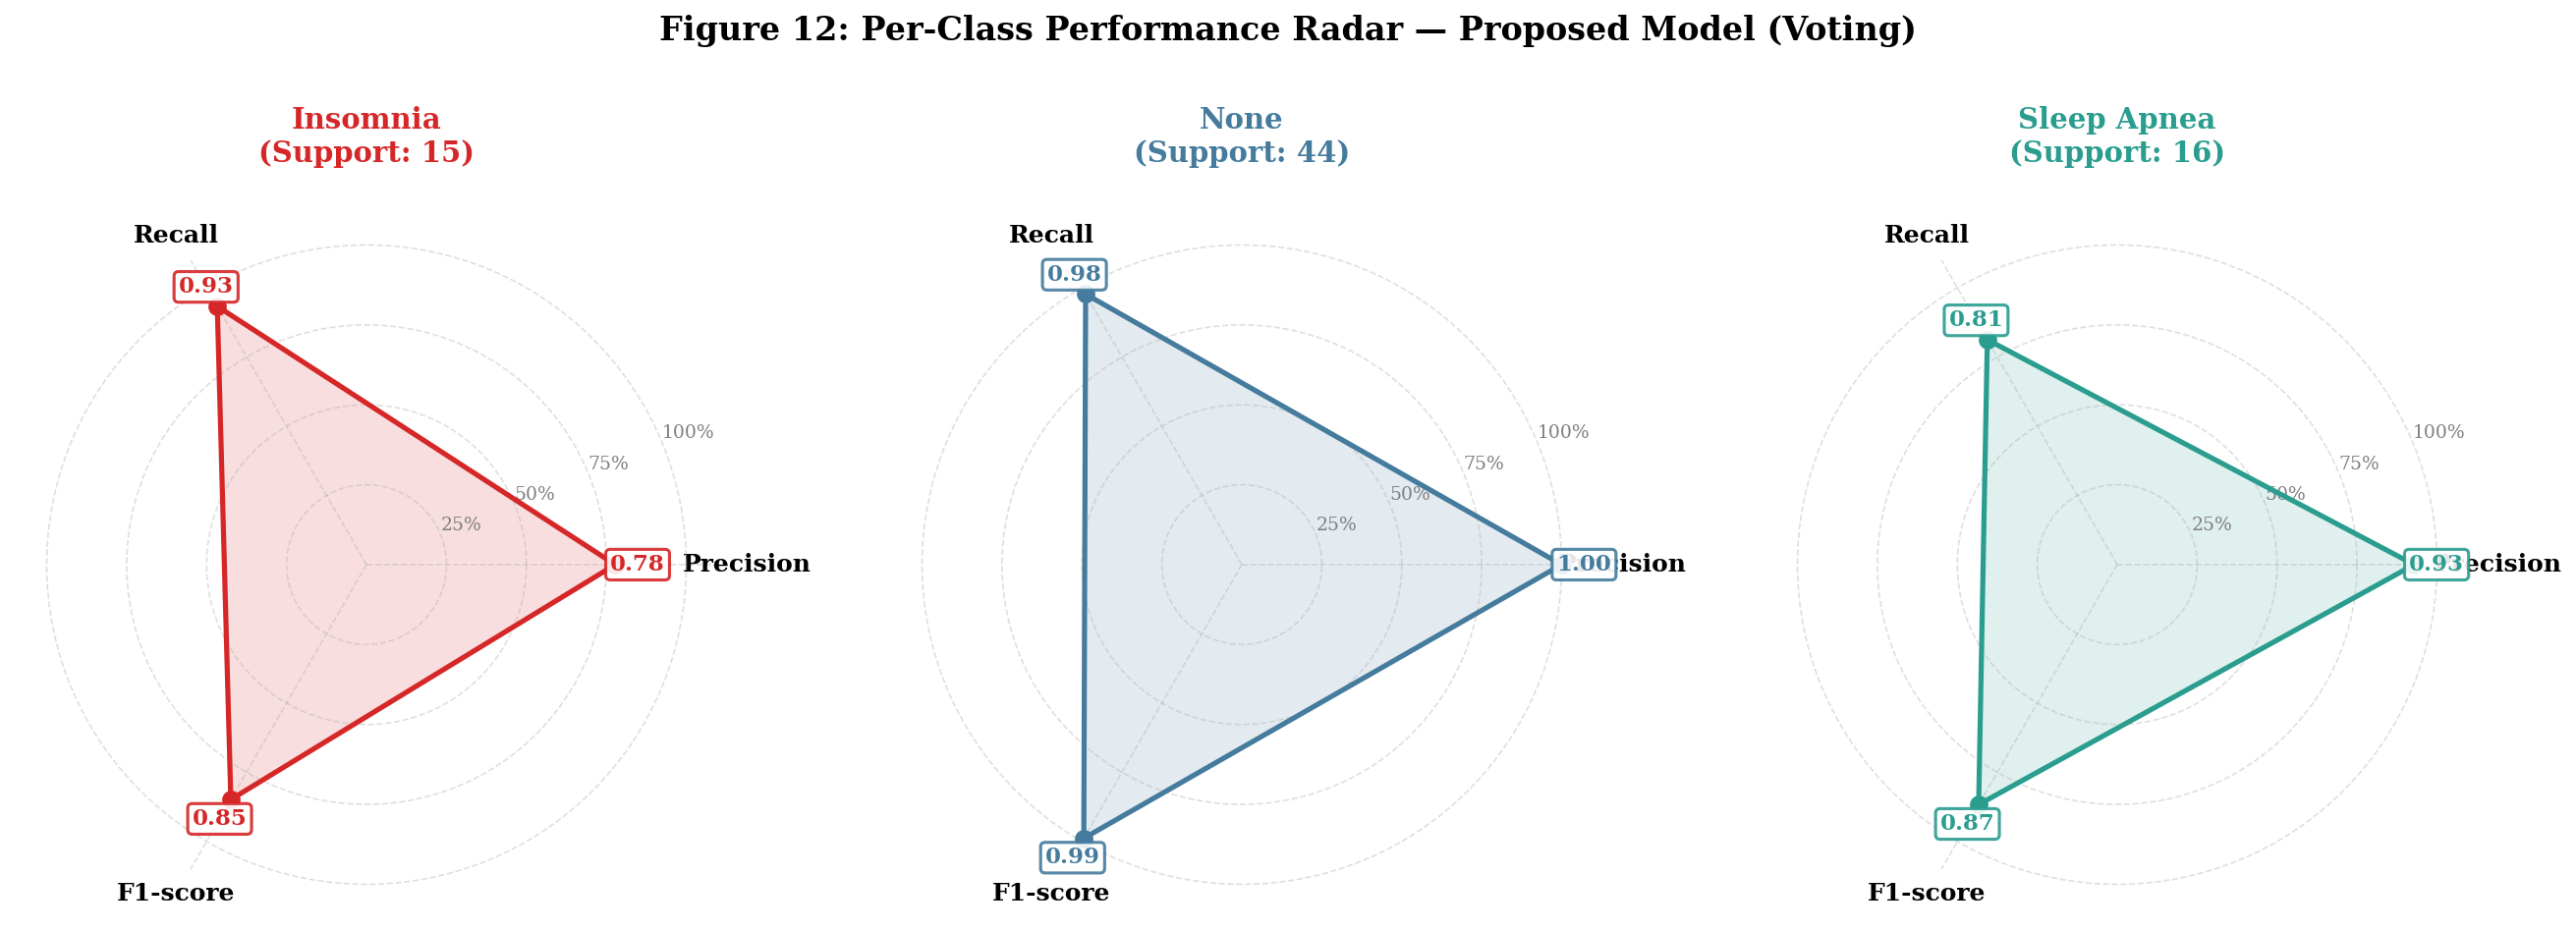

In [24]:
# ============================================================
# Figure 12: Per-Class Metric Radar Chart
# ============================================================
import textwrap

report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
radar_metrics = ['precision', 'recall', 'f1-score']
class_names = list(le.classes_)

fig, axes = plt.subplots(1, len(class_names), figsize=(6 * len(class_names), 6),
                          subplot_kw={'polar': True})
colors_radar = ['#d62728', '#457b9d', '#2a9d8f']

for idx, (cls, color) in enumerate(zip(class_names, colors_radar)):
    ax = axes[idx]
    values = [report[cls][m] for m in radar_metrics]
    values += values[:1]  # close the radar
    
    angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
    angles += angles[:1]
    
    ax.fill(angles, values, color=color, alpha=0.15)
    ax.plot(angles, values, 'o-', color=color, lw=2.5, markersize=8)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([m.capitalize() for m in radar_metrics], fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_yticks([0.25, 0.50, 0.75, 1.00])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=9, color='gray')
    ax.set_title(f'{cls}\n(Support: {report[cls]["support"]:.0f})',
                 fontsize=14, fontweight='bold', pad=25, color=color)
    
    # Thicker grid for radar
    ax.grid(alpha=0.4, linestyle='--')
    ax.spines['polar'].set_visible(False)
    
    # Annotate values with a clean background box
    for angle, val in zip(angles[:-1], values[:-1]):
        ax.text(angle, val + 0.07, f'{val:.2f}', ha='center', va='center',
                fontsize=11, fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor=color, alpha=0.9, linewidth=1.5))

plt.suptitle('Figure 12: Per-Class Performance Radar \u2014 Proposed Model (Voting)',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Figure 13: Training Time Comparison

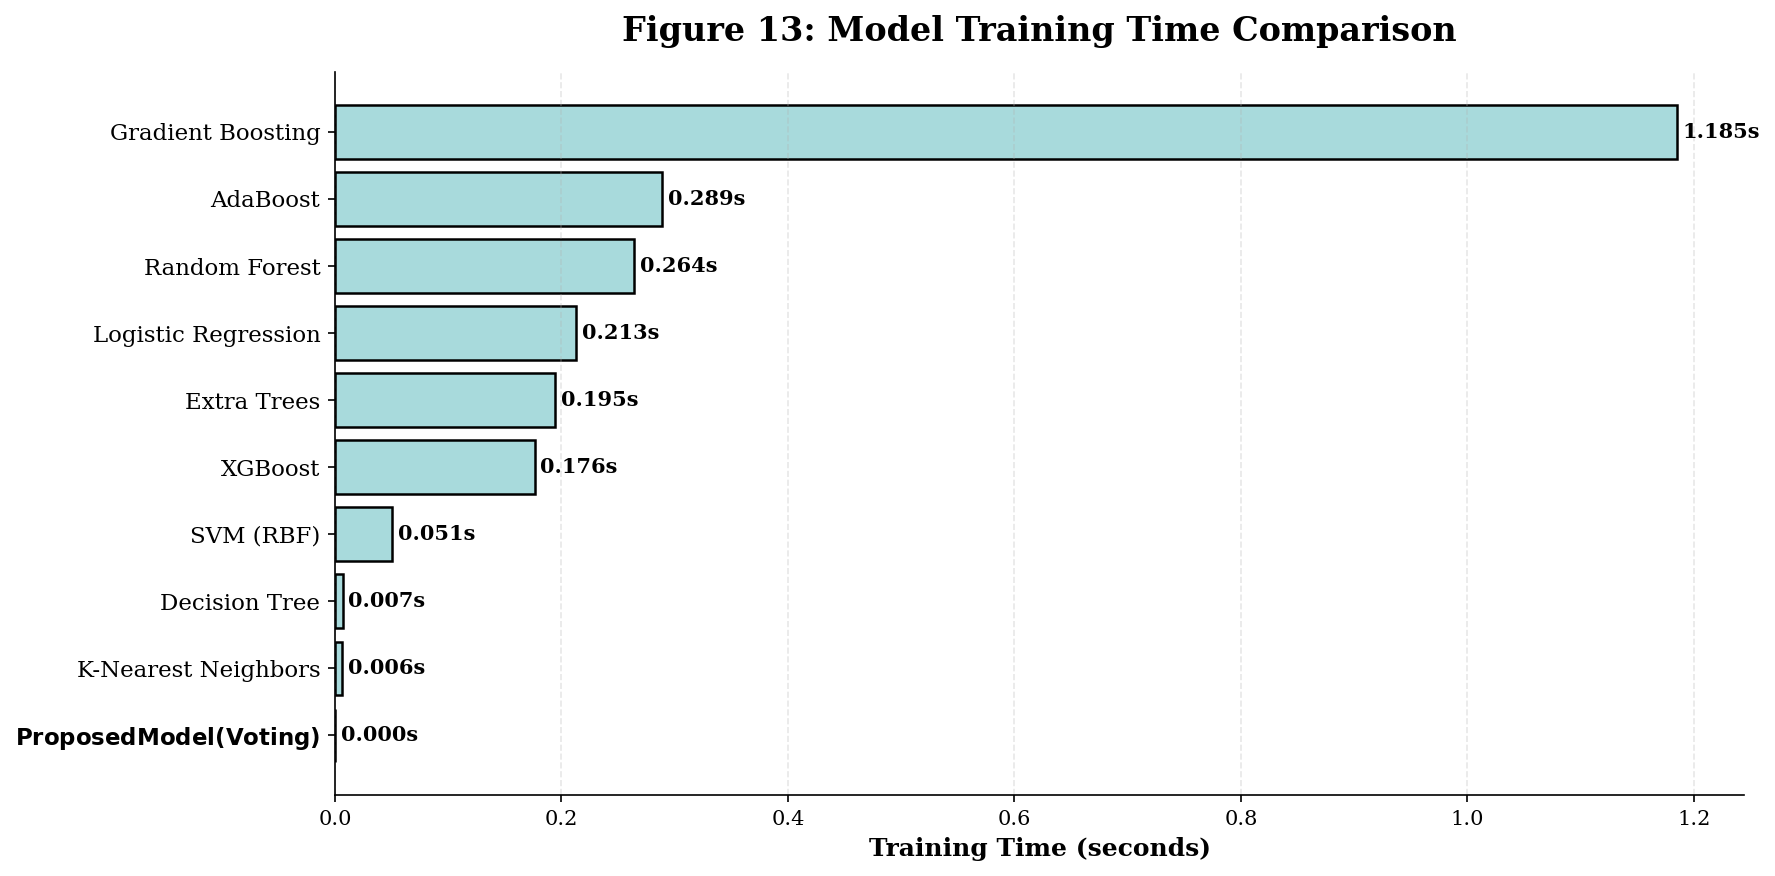

In [25]:
# ============================================================
# Figure 13: Training Time Comparison
# ============================================================
time_df = pd.DataFrame(list(train_times.items()), columns=['Model', 'Time (s)'])
time_df = time_df.sort_values('Time (s)', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))

# Highlight the proposed model
bar_colors = ['#d62728' if 'Proposed' in m else '#a8dadc' for m in time_df['Model']]
bars = ax.barh(time_df['Model'], time_df['Time (s)'], color=bar_colors,
               edgecolor='black', linewidth=1.2)

for bar, model_name in zip(bars, time_df['Model']):
    if 'Proposed' in model_name:
        bar.set_hatch('//')

for bar, val in zip(bars, time_df['Time (s)']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}s', va='center', fontsize=10, fontweight='bold', color='black')

# Bold the label for proposed model
yticklabels = [f"$\\bf{{{m}}}$" if 'Proposed' in m else m for m in time_df['Model']]
ax.set_yticklabels(yticklabels, fontsize=11)

ax.set_xlabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Figure 13: Model Training Time Comparison', fontsize=16, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Figure 14: Feature Distribution Violin Plots by Sleep Disorder Class

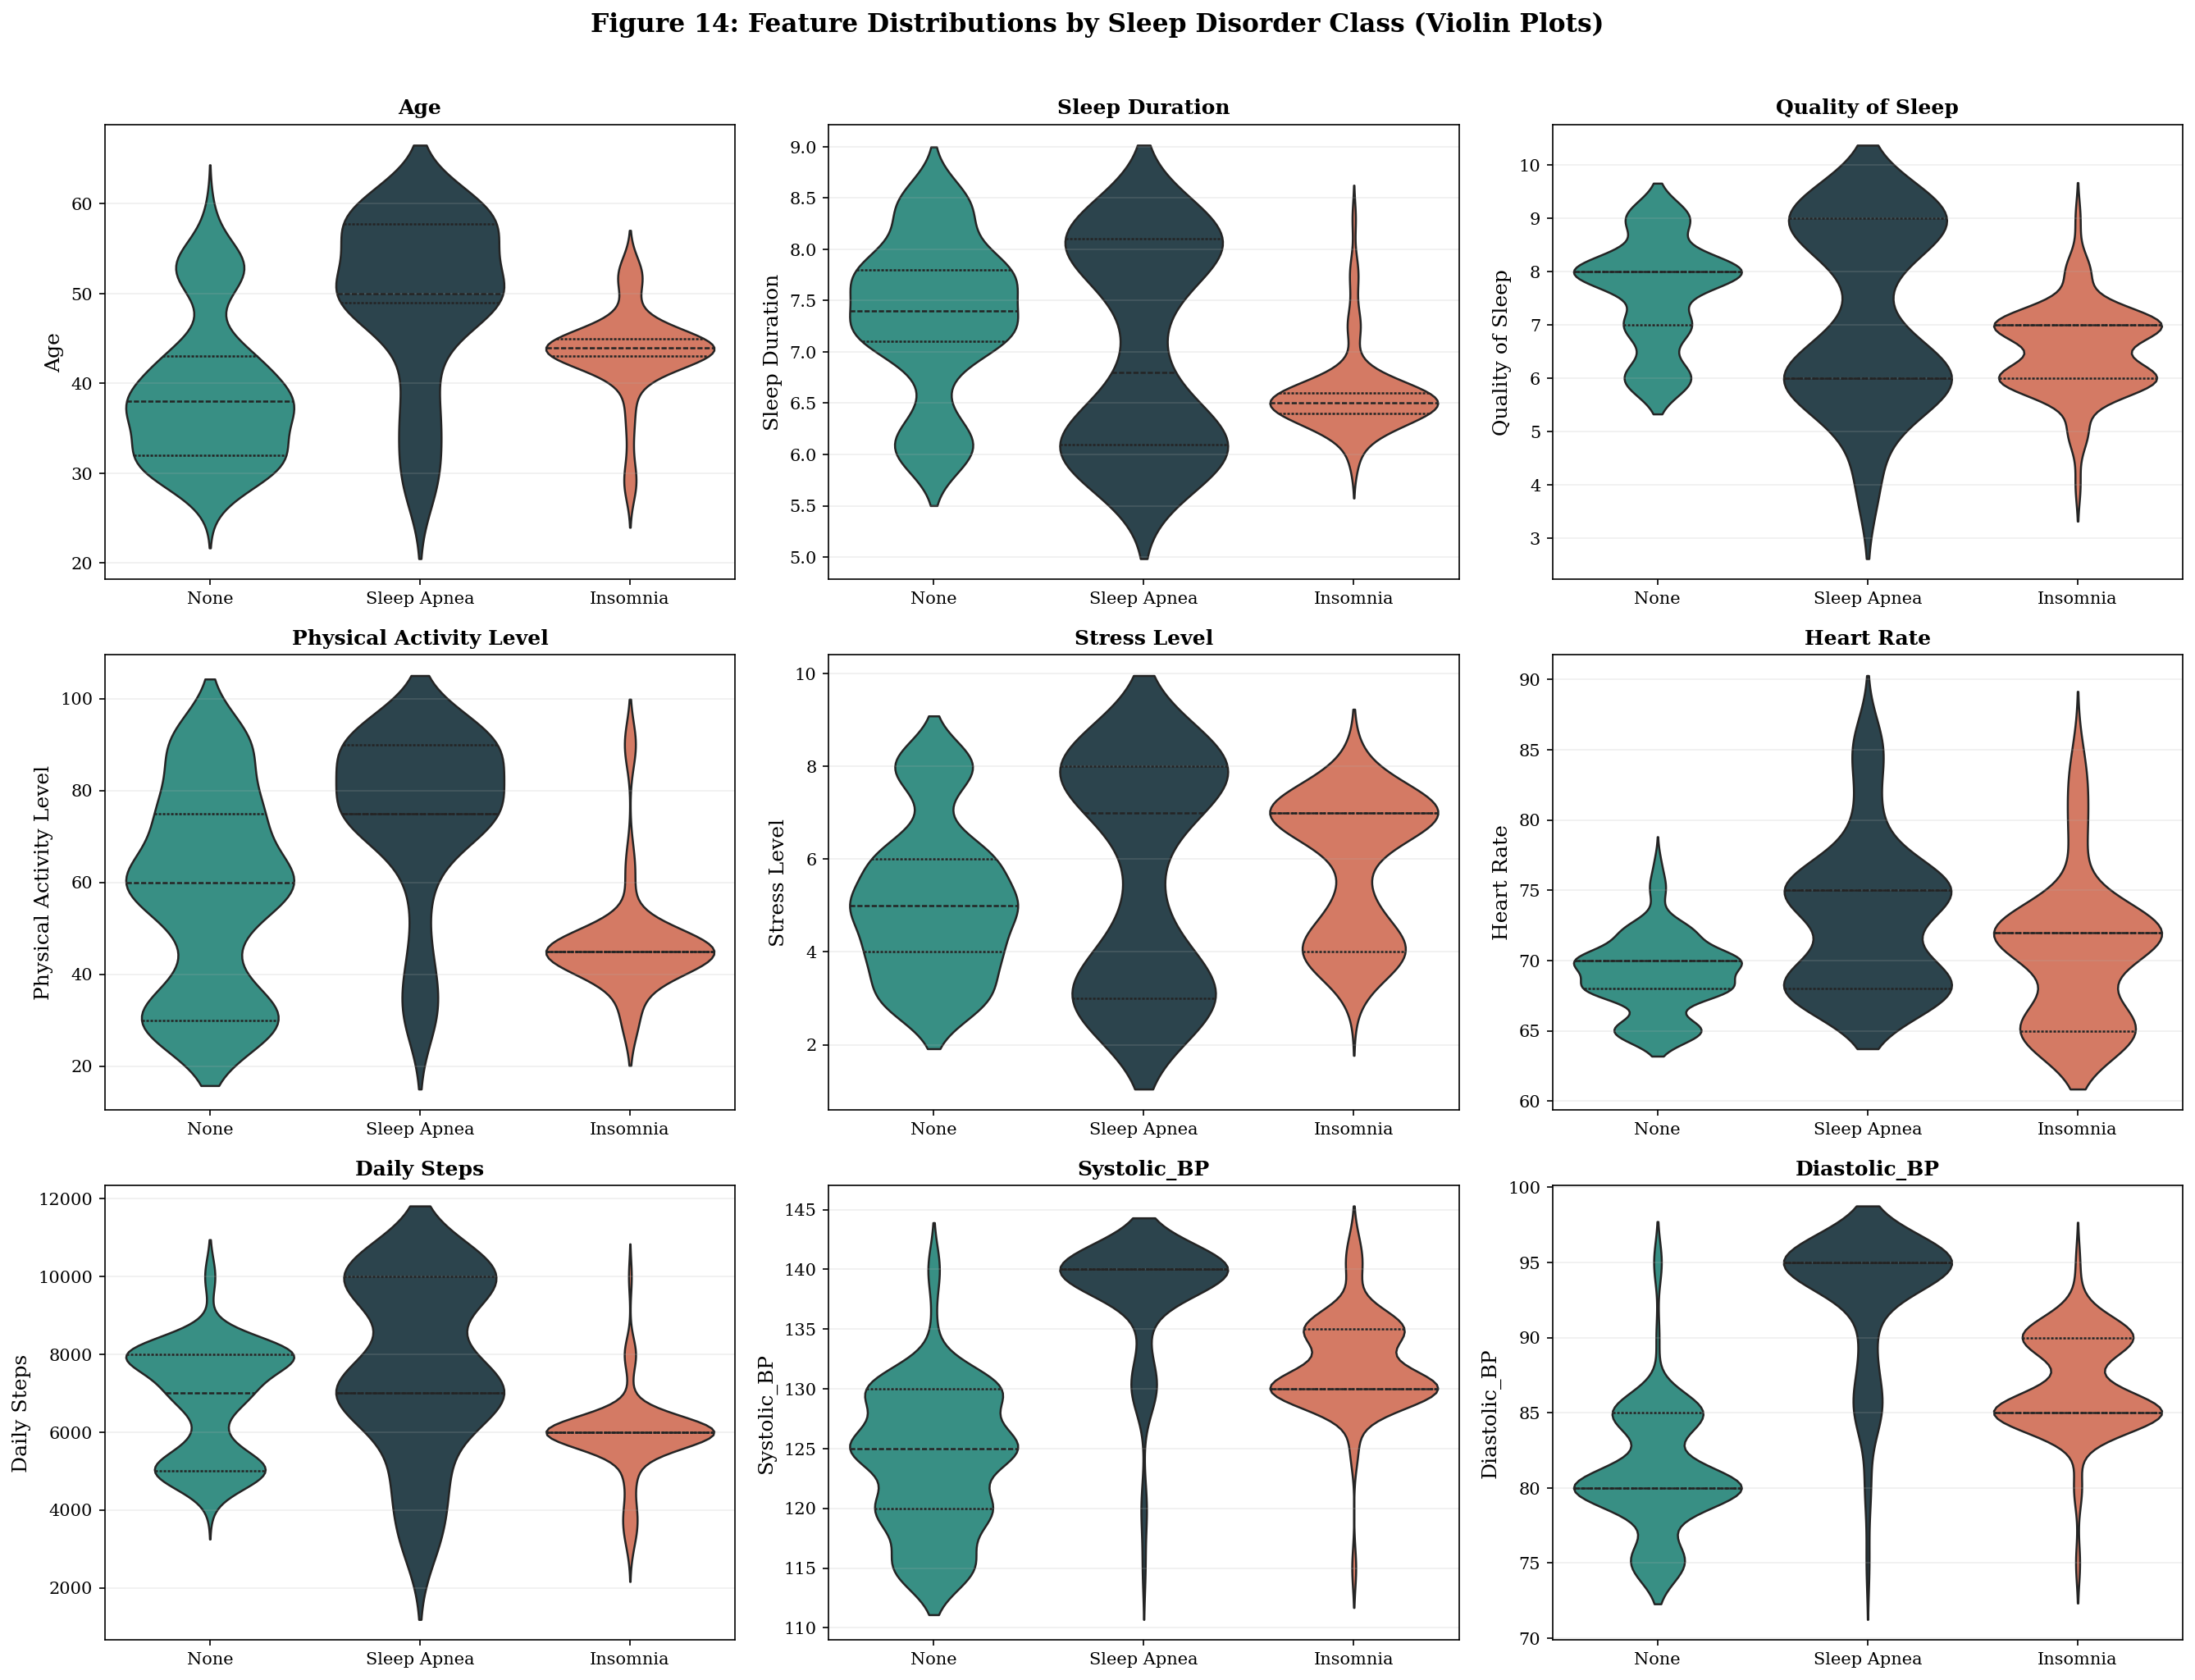

In [26]:
# ============================================================
# Figure 14: Feature Distribution Violin Plots
# ============================================================
num_features = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP']
available_features = [f for f in num_features if f in df.columns]

n_feat = len(available_features)
n_cols = 3
n_rows = int(np.ceil(n_feat / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes_flat = axes.flatten()

palette = {'None': '#2a9d8f', 'Insomnia': '#e76f51', 'Sleep Apnea': '#264653'}

for idx, feat in enumerate(available_features):
    ax = axes_flat[idx]
    sns.violinplot(data=df, x='Sleep Disorder', y=feat, ax=ax,
                   palette=palette, inner='quartile', linewidth=1.2)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.2)

# Hide unused axes
for idx in range(n_feat, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Figure 14: Feature Distributions by Sleep Disorder Class (Violin Plots)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Figure 15: Comprehensive Model Comparison Summary — Radar & Table

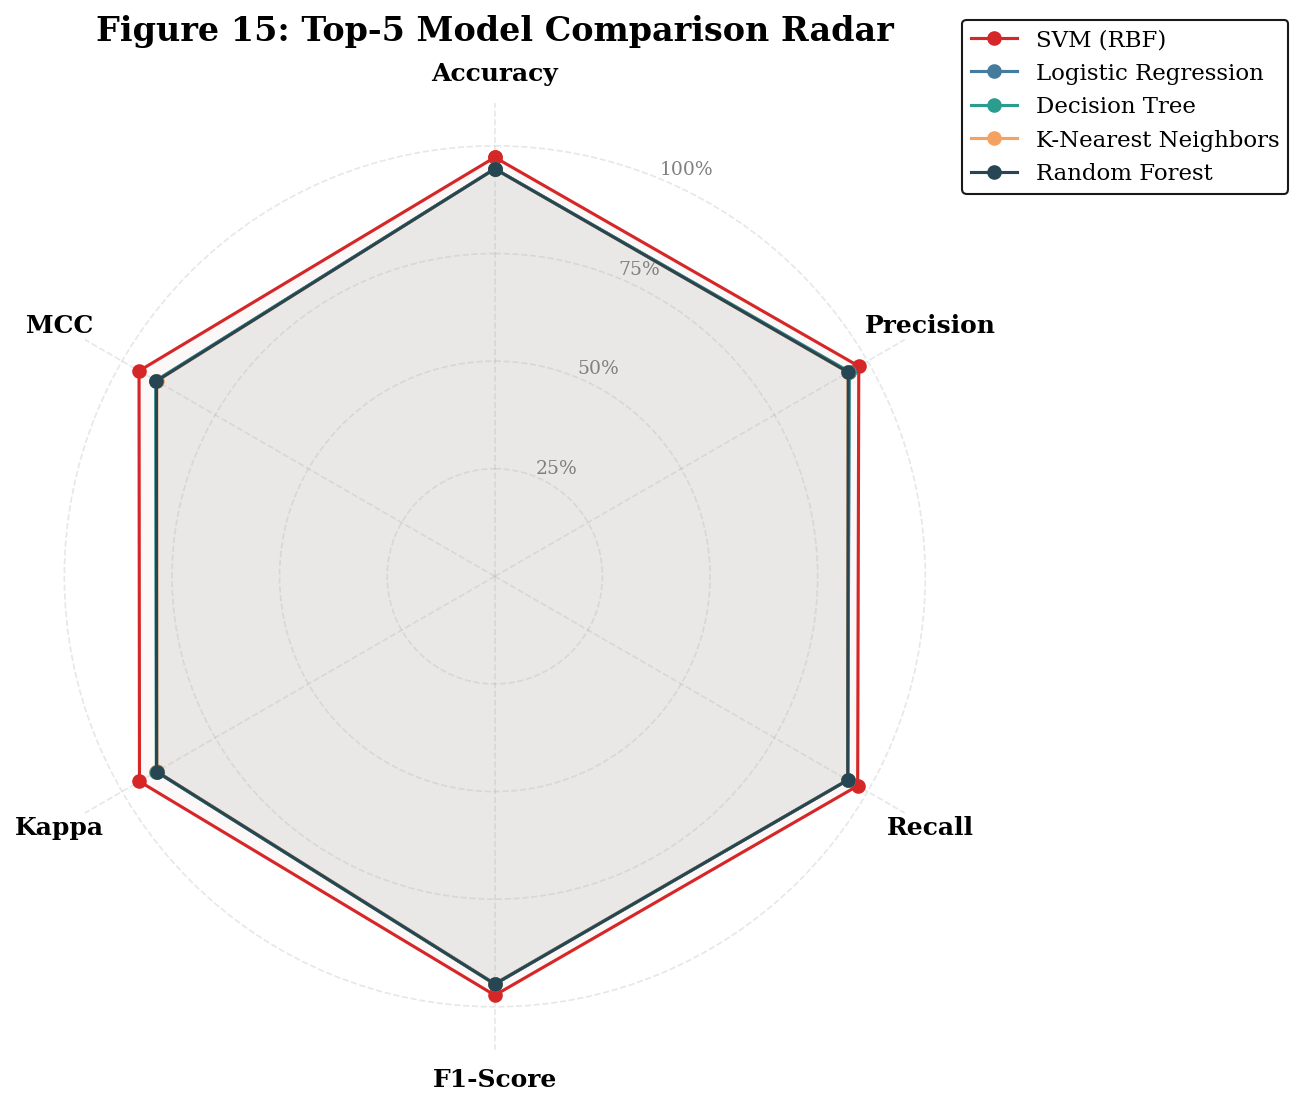


FINAL MODEL COMPARISON SUMMARY TABLE
                         Accuracy  Precision    Recall  F1-Score     Kappa       MCC  Log Loss
SVM (RBF)                0.973333   0.976296  0.973333  0.973165  0.953213  0.954405  0.198935
Logistic Regression      0.946667   0.950931  0.946667  0.946400  0.907236  0.909219  0.200908
Decision Tree            0.946667   0.949902  0.946667  0.947608  0.908116  0.909076  1.999130
K-Nearest Neighbors      0.946667   0.947444  0.946667  0.946667  0.906513  0.906796  0.191919
Random Forest            0.946667   0.948235  0.946667  0.947196  0.907293  0.907605  0.189999
XGBoost                  0.946667   0.949468  0.946667  0.946556  0.906542  0.907673  0.190695
Gradient Boosting        0.946667   0.948235  0.946667  0.947196  0.907293  0.907605  0.367404
Extra Trees              0.933333   0.940317  0.933333  0.934509  0.884224  0.886163  1.579821
Proposed Model (Voting)  0.933333   0.940317  0.933333  0.934509  0.884224  0.886163  0.186473
AdaBoost    

In [27]:
# ============================================================
# Figure 15: Multi-Model Comparison Radar (Top 5 Models)
# ============================================================
import textwrap

top5 = results_df.head(5)
metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Kappa', 'MCC']
colors_top5 = ['#d62728', '#457b9d', '#2a9d8f', '#f4a261', '#264653']

n_metrics = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'polar': True})
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

for (model_name, row), color in zip(top5.iterrows(), colors_top5):
    values = [row[m] for m in metrics_radar]
    values += values[:1]
    
    is_proposed = 'Proposed' in model_name
    c = '#d62728' if is_proposed else color
    lw = 4.0 if is_proposed else 1.5
    alpha = 0.15 if is_proposed else 0.03
    z = 10 if is_proposed else 2
    ms = 10 if is_proposed else 6
    marker = '*' if is_proposed else 'o'
    
    ax.plot(angles, values, marker=marker, color=c, lw=lw, markersize=ms, label=model_name, zorder=z)
    ax.fill(angles, values, color=c, alpha=alpha, zorder=z-1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=9, color='gray')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11, framealpha=0.9, edgecolor='black')
ax.set_title('Figure 15: Top-5 Model Comparison Radar',
             fontsize=16, fontweight='bold', pad=30)
ax.grid(alpha=0.3, linestyle='--')
ax.spines['polar'].set_visible(False)

plt.tight_layout()
plt.show()

# Print final summary table
print("\n" + "="*80)
print("FINAL MODEL COMPARISON SUMMARY TABLE")
print("="*80)
print(results_df[metrics_radar + ['Log Loss']].to_string())
print("="*80)

PermutationExplainer explainer: 11it [00:18,  1.85s/it]                        


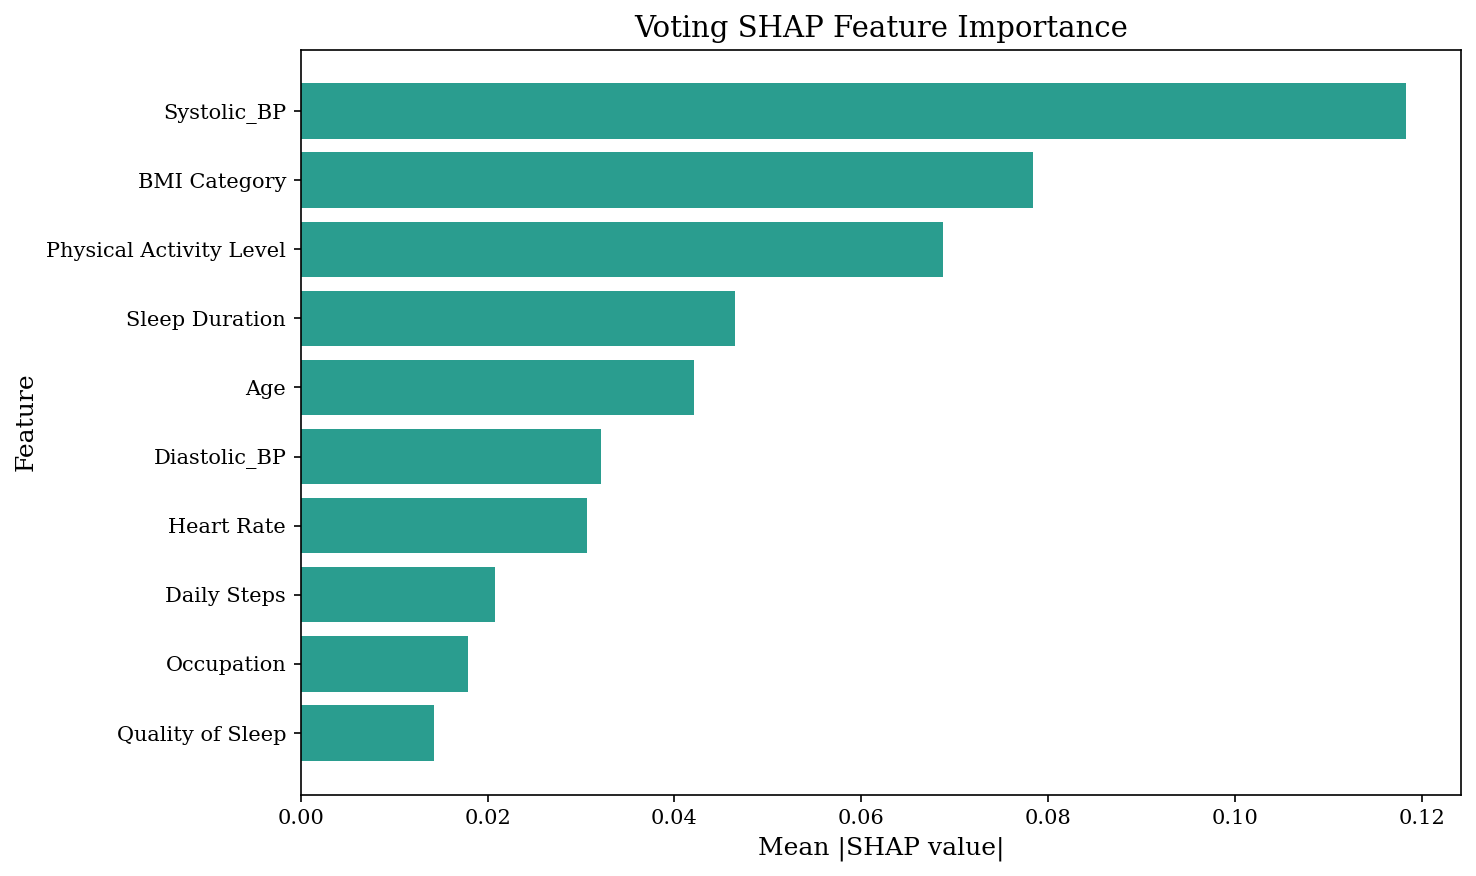

In [28]:
# Requires shap and lime; install from requirements.txt.
import shap

model_label = "Voting"
explain_model = voting_model

feature_names = X_train.columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = [col for col in feature_names if col not in categorical_cols]

# Encode categorical features so SHAP and LIME can work on the raw input space.
category_maps = {}
encoded_train = X_train.copy()
encoded_test = X_test.copy()

for col in categorical_cols:
    categories = list(pd.Index(X_train[col].astype(str).unique()))
    mapping = {value: idx for idx, value in enumerate(categories)}
    category_maps[col] = mapping
    encoded_train[col] = X_train[col].astype(str).map(mapping).astype(float)
    encoded_test[col] = X_test[col].astype(str).map(mapping).astype(float)


def decode_encoded_frame(encoded_array):
    encoded_array = np.asarray(encoded_array)
    if encoded_array.ndim == 1:
        encoded_array = encoded_array.reshape(1, -1)
    decoded = pd.DataFrame(encoded_array, columns=feature_names)
    for col in categorical_cols:
        inverse_map = {code: label for label, code in category_maps[col].items()}
        codes = pd.to_numeric(decoded[col], errors="coerce").fillna(0).round().astype(int)
        codes = codes.clip(0, len(inverse_map) - 1)
        decoded[col] = codes.map(inverse_map)
    for col in numerical_cols:
        decoded[col] = pd.to_numeric(decoded[col], errors="coerce")
    return decoded


def predict_proba_from_encoded(encoded_array):
    return explain_model.predict_proba(decode_encoded_frame(encoded_array))

encoded_train_array = encoded_train[feature_names].to_numpy(dtype=float)
encoded_test_array = encoded_test[feature_names].to_numpy(dtype=float)

background = shap.sample(encoded_train_array, min(30, len(encoded_train_array)), random_state=42)
sample_rows = encoded_test_array[:min(10, len(encoded_test_array))]

masker = shap.maskers.Independent(background)
shap_explainer = shap.Explainer(
    predict_proba_from_encoded,
    masker,
    feature_names=feature_names,
    algorithm="permutation",
)
shap_values = shap_explainer(sample_rows)

if shap_values.values.ndim == 3:
    mean_abs_shap = np.mean(np.abs(shap_values.values), axis=(0, 2))
else:
    mean_abs_shap = np.mean(np.abs(shap_values.values), axis=0)

shap_importance = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False)

top_shap = shap_importance.head(10).iloc[::-1]
plt.figure(figsize=(10, 6))
plt.barh(top_shap.index, top_shap.values, color="#2a9d8f")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title(f"{model_label} SHAP Feature Importance")
plt.tight_layout()
plt.show()

Actual label: Insomnia
Predicted label: Insomnia
Prediction probabilities: {'Insomnia': 0.9866, 'None': 0.012, 'Sleep Apnea': 0.0014}


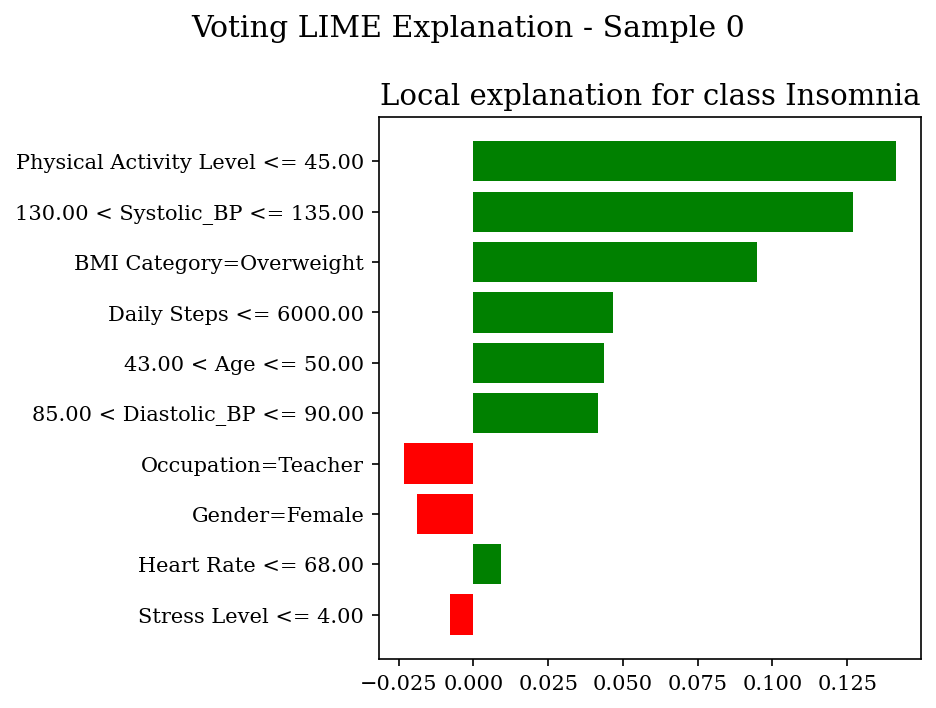

In [29]:
from lime.lime_tabular import LimeTabularExplainer

categorical_feature_indices = [feature_names.index(col) for col in categorical_cols]
categorical_names = {
    feature_names.index(col): list(category_maps[col].keys())
    for col in categorical_cols
}

lime_explainer = LimeTabularExplainer(
    training_data=encoded_train_array,
    feature_names=feature_names,
    class_names=list(le.classes_),
    categorical_features=categorical_feature_indices,
    categorical_names=categorical_names,
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

sample_idx = 0
sample_instance = encoded_test_array[sample_idx]
sample_probs = predict_proba_from_encoded(sample_instance)[0]
sample_pred_idx = int(np.argmax(sample_probs))
sample_pred_label = le.inverse_transform([sample_pred_idx])[0]
sample_true_label = le.inverse_transform([int(np.asarray(y_test)[sample_idx])])[0]

lime_exp = lime_explainer.explain_instance(
    sample_instance,
    predict_proba_from_encoded,
    num_features=min(10, len(feature_names)),
    top_labels=1,
)

print("Actual label:", sample_true_label)
print("Predicted label:", sample_pred_label)
print("Prediction probabilities:", dict(zip(le.classes_, np.round(sample_probs, 4))))

fig = lime_exp.as_pyplot_figure(label=sample_pred_idx)
fig.suptitle(f"{model_label} LIME Explanation - Sample {sample_idx}")
fig.tight_layout()
plt.show()
